
# Project: Patient‑Readable Clinical Trial Summaries

**Goal (Milestone P2):** Build a reproducible **data understanding + preprocessing + descriptive statistics** notebook that prepares us to generate **patient‑friendly summaries** from English clinical trial records https://huggingface.co/datasets/louisbrulenaudet/clinical-trials.
We focus on three pillars:
1. **Too much jargon** → measure complexity and technical vocabulary.
2. **Patient‑friendly description** → characterize what we need to simplify (length, readability).
3. **Transparent explanations** → prepare metadata to support glossaries and “who/what/why/how” summaries.

**What this notebook shows:**
- That we can **load and handle** the dataset at scale.
- That we **understand the data** (formats, missingness, enrich, correlations).
- That we have a **ready dataset** to work with toward simplification + summarization.



## Part 1: Feature understanding
- We select the necessary features
- We address missing values
- We consider length of the data
- We enrich some features

### Subtask 1: Data loading

We load the Hugging Face dataset **`louisbrulenaudet/clinical-trials`**, report the number of rows,
and print the feature names and types as sanity check.

In [1]:
from datasets import load_dataset

# Load the complete dataset
dataset = load_dataset("louisbrulenaudet/clinical-trials", split="train")

print(f"Dataset size: {len(dataset)}")
print(f"Features: {dataset.features}")

C:\Users\Flaviu\miniconda3\envs\nlp\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Dataset size: 541897
Features: {'nct_id': Value('string'), 'updated_at': Value('timestamp[us]'), 'brief_title': Value('string'), 'official_title': Value('string'), 'acronym': Value('string'), 'study_type': Value('string'), 'overall_status': Value('string'), 'study_first_submit_date': Value('timestamp[ms]'), 'start_date': Value('timestamp[ms]'), 'primary_completion_date': Value('timestamp[ms]'), 'completion_date': Value('timestamp[ms]'), 'phases': List(Value('string')), 'enrollment_count': Value('float64'), 'minimum_age': Value('float64'), 'maximum_age': Value('float64'), 'sex': Value('string'), 'healthy_volunteers': Value('bool'), 'brief_summary': Value('string'), 'detailed_description': Value('string'), 'eligibility_criteria': Value('string'), 'lead_sponsor_name': Value('string'), 'lead_sponsor_class': Value('string'), 'org_study_id_info': {'id': Value('string'), 'link': Value('string'), 'type': Value('string')}, 'why_stopped': Value('string'), 'expanded_access_info': {'hasExpandedAcc

In [2]:
print("Number of features: ", len(dataset.features))

Number of features:  46


Our main features will be "detailed_description" and "brief_summary". Let's see how many rows are missing those features.

In [3]:
print(len(dataset))
print("Without brief summary: ", dataset['brief_summary'].count(None))
print("Without detailed_description: ", dataset['detailed_description'].count(None))

541897
Without brief summary:  920
Without detailed_description:  175870


Looks like 1/3 of the data is missing the detailed description. A big number, but we consider that it still leaves us enough samples to work on. We will address this later, now let's look at some random samples:

In [7]:
import textwrap
import random
# --- Random rows peek ---
k = 3
idxs = random.sample(range(len(dataset)), k)
peek = dataset.select(idxs)
for i, row in enumerate(peek):
    print(f"\n--- Random row {i+1} (index={idxs[i]}) ---")
    # Print key fields for readability
    for key in [
        "nct_id", "brief_title", "study_type", "overall_status",
        "phases", "conditions", "minimum_age", "maximum_age", "sex",
        "brief_summary", "detailed_description"
    ]:
        if key in row:
            val = row[key]
            if isinstance(val, str) and len(val) > 500:
                val = textwrap.shorten(val, width=500, placeholder=" ...")
            print(f"{key}: {val}")


--- Random row 1 (index=204184) ---
nct_id: NCT06868446
brief_title: Feasibility of a Digital Therapeutic for Adults with Posttraumatic Stress Disorder (PTSD)
study_type: INTERVENTIONAL
overall_status: NOT_YET_RECRUITING
phases: ['PHASE1']
conditions: ['PTSD', 'Post Traumatic Stress Disorder']
minimum_age: 18.0
maximum_age: None
sex: ALL
brief_summary: This study is exploring the efficacy of a digital therapeutic app in reducing symptoms of posttraumatic stress disorder (PTSD) in adults.
detailed_description: The purpose of this study is to conduct a randomized controlled trial to evaluate the usability and feasibility as well as the safety and effectiveness of OTX-601 (version 1) + TAU compared to OTX-601 (version 2) + TAU in reducing PTSD symptoms from baseline to 7 weeks.

--- Random row 2 (index=246533) ---
nct_id: NCT05211596
brief_title: Deaf Weight Wise: Community-engaged Implementation Research to Promote Healthy Lifestyle Change With Deaf American Sign Language Users
study_ty

### Subtask 2: Selecting necessary features

After manually looking through the dataset and at the description provided at https://huggingface.co/datasets/louisbrulenaudet/clinical-trials, we selected the features we found relevant and created a feature plan. This table documents which fields we **keep**, which are **optional**, and which we **drop**, including the rationale. The **keep** features are the ones we will use for summarization; the **optional** ones are those which we consider that might give us some info in case the **keep** are not sufficient; **drop** features are those we consider do not give any important information for patients.

In [4]:
import pandas as pd

# --- Feature plan (keep/drop + justification) ---
plan_rows = [
    dict(field="nct_id", use="keep", role="identifier", justification="Unique trial ID for traceability/provenance."),
    dict(field="detailed_description", use="keep", role="primary_text", justification="Main source for simplification & summarization."),
    dict(field="brief_summary", use="keep", role="reference_text", justification="Comparison target for coverage & readability diffs."),
    dict(field="brief_title", use="keep", role="aux_text", justification="Concise signal of condition/intervention; useful for summaries."),
    dict(field="official_title", use="keep", role="aux_text", justification="Formal title; may provide specific terminology."),
    dict(field="study_type", use="keep", role="metadata", justification="Context for wording (interventional vs observational)."),
    dict(field="overall_status", use="keep", role="metadata", justification="Status cues phrasing and may affect inclusion."),
    dict(field="phases", use="drop", role="metadata", justification="Do not provide valuable information for trail description."),
    dict(field="conditions", use="keep", role="metadata", justification="Key to patient relevance; appears in the summary."),
    dict(field="minimum_age", use="keep", role="metadata", justification="Eligibility snippet (age bounds)."),
    dict(field="maximum_age", use="keep", role="metadata", justification="Eligibility snippet (age bounds)."),
    dict(field="sex", use="keep", role="metadata", justification="Eligibility snippet (sex)."),
    dict(field="healthy_volunteers", use="keep", role="metadata", justification="May be useful for eligibility sentences."),
    dict(field="eligibility_criteria", use="keep", role="aux_text", justification="Source for ‘for whom’ phrasing; optional extraction."),
    dict(field="lead_sponsor_name", use="optional", role="metadata", justification="Provenance; not typically in lay summary."),
    dict(field="lead_sponsor_class", use="drop", role="metadata", justification="Likely irrelevant for patient-facing text."),
    dict(field="enrollment_count", use="optional", role="metadata", justification="Contextual statistic; might be mentioned sparingly."),
    dict(field="start_date", use="optional", role="metadata", justification="Timeline context if needed."),
    dict(field="primary_completion_date", use="drop", role="metadata", justification="Timeline context probably needed."),
    dict(field="completion_date", use="drop", role="metadata", justification="Timeline context probably not needed."),
    dict(field="keywords", use="keep", role="aux_text", justification="May seed domain vocabulary/jargon detection."),
    dict(field="locations", use="optional", role="metadata", justification="High-level geography; not always needed in summary."),
    dict(field="overall_officials", use="drop", role="metadata", justification="Low value for lay summary text."),
    dict(field="outcomes", use="keep", role="metadata", justification="Primary/secondary measures inform ‘what is measured’."),
    dict(field="design_info", use="keep", role="metadata", justification="Randomization/masking/purpose → plain-language explanation."),
    dict(field="mesh_terms", use="optional", role="metadata", justification="Useful for controlled vocabulary/jargon mapping."),
    dict(field="condition_browse_module", use="drop", role="metadata", justification="Taxonomy signs; probably not needed."),
    dict(field="intervention_browse_module", use="drop", role="metadata", justification="Taxonomy signs; probably not."),
    dict(field="why_stopped", use="optional", role="metadata", justification="If terminated, can inform a cautionary note in summary."),
    dict(field="expanded_access_info", use="drop", role="metadata", justification="Out-of-scope for lay summary generation."),
    dict(field="org_study_id_info", use="drop", role="metadata", justification="Administrative; not needed for text generation."),
    dict(field="arm_groups", use="optional", role="metadata", justification="If present, may help clarify groups in lay terms."),
    dict(field="interventions", use="keep", role="metadata", justification="Names/types of interventions: key to ‘what is tested’."),
    dict(field="study_references", use="drop", role="metadata", justification="Not needed for lay summary text."),
    dict(field="misc_info_module", use="drop", role="metadata", justification="Likely non-essential for our task."),
    dict(field="updated_at", use="optional", role="metadata", justification="Recency; can be used for filtering if needed."),
    dict(field="last_update_submit_qc_date", use="drop", role="metadata", justification="Quality control recency; drio for simplicity."),
    dict(field="last_update_post_date_struct", use="drop", role="metadata", justification="Administrative; drop for simplicity."),
    dict(field="study_first_post_date_struct", use="drop", role="metadata", justification="Administrative; drop for simplicity."),
    dict(field="study_first_submit_date", use="drop", role="metadata", justification="Administrative; drop for simplicity."),
    dict(field="std_ages", use="optional", role="metadata", justification="Age categories; redundant with min/max but handy."),
    dict(field="sampling_method", use="optional", role="metadata", justification="May inform wording but often technical."),
    dict(field="oversight_has_dmc", use="drop", role="metadata", justification="Oversight detail; too technical for lay summary."),
    dict(field="collaborators", use="drop", role="metadata", justification="Attribution; not needed in lay summary."),
    dict(field="acronym", use="drop", role="metadata", justification="Not relevant"),
    dict(field="study_population", use="keep", role="metadata", justification="Summary of the needed study population."),
]
plan_df = pd.DataFrame(plan_rows, columns=["field","use","role","justification"])
print(len(plan_df))
plan_df.to_csv("feature_plan.csv", index=False)

def df_to_markdown(df: pd.DataFrame) -> str:
    return df.to_markdown(index=False)

print("\n=== Feature Plan (Markdown) ===")
print(plan_df.to_markdown(index=False))


46

=== Feature Plan (Markdown) ===
| field                        | use      | role           | justification                                                   |
|:-----------------------------|:---------|:---------------|:----------------------------------------------------------------|
| nct_id                       | keep     | identifier     | Unique trial ID for traceability/provenance.                    |
| detailed_description         | keep     | primary_text   | Main source for simplification & summarization.                 |
| brief_summary                | keep     | reference_text | Comparison target for coverage & readability diffs.             |
| brief_title                  | keep     | aux_text       | Concise signal of condition/intervention; useful for summaries. |
| official_title               | keep     | aux_text       | Formal title; may provide specific terminology.                 |
| study_type                   | keep     | metadata       | Context for wo

Our current idea is that we will combine the features marked as "keep" in a method like: "title: ..., description: ..., eligibility criteria: ..., ....." and use this new text as data to fine-tune our pretrained model for P3.

### Subtask 3: Visualize and address missing values

We compute **missing values** per field and visualize top offenders.
**Why:** understanding completeness helps us define **filters** (e.g., drop rows with empty `detailed_description`) and
estimate how much usable data remains for modeling. (For us: **TAKES 4 MIN TO RUN**)

In [5]:
# --- Step 3: Assess data volume & missingness ---

import numpy as np
import math
import matplotlib.pyplot as plt
from collections.abc import Mapping, Sequence

# 3.1 Choose fields to assess (driven by our plan)
# We'll check all "keep" fields that are present in the dataset.
candidate_fields = [f for f in plan_df.query("use in ['keep']")["field"].tolist()
                    if f in dataset.column_names]

# 3.2 Helpers to decide what's "missing" (works for str, lists, dicts, None, NaN)
def is_missing_value(v):
    if v is None:
        return True
    # NaN (numbers)
    try:
        if isinstance(v, float) and math.isnan(v):
            return True
    except Exception:
        pass
    # Empty string or whitespace-only
    if isinstance(v, str):
        return len(v.strip()) == 0
    # Empty list/tuple
    if isinstance(v, Sequence) and not isinstance(v, (str, bytes)):
        return len(v) == 0
    # Empty dict
    if isinstance(v, Mapping):
        return len(v) == 0
    return False

# 3.3 Compute missingness per field (percentage)
missing_rows = []
N = len(dataset)
for field in candidate_fields:
    col = dataset[field]
    miss_cnt = sum(is_missing_value(v) for v in col)
    missing_rows.append({
        "field": field,
        "num_missing": miss_cnt,
        "pct_missing": 100.0 * miss_cnt / N
    })

missing_df = pd.DataFrame(missing_rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
missing_df


,field,num_missing,pct_missing
0,interventions,541897,100.000000
1,study_population,420133,77.530047
2,maximum_age,254447,46.954864
3,keywords,201556,37.194522
4,detailed_description,175870,32.454507
5,minimum_age,36025,6.647942
6,outcomes,17510,3.231241
7,healthy_volunteers,13771,2.541258
8,official_title,9986,1.842786
9,design_info,4664,0.860680


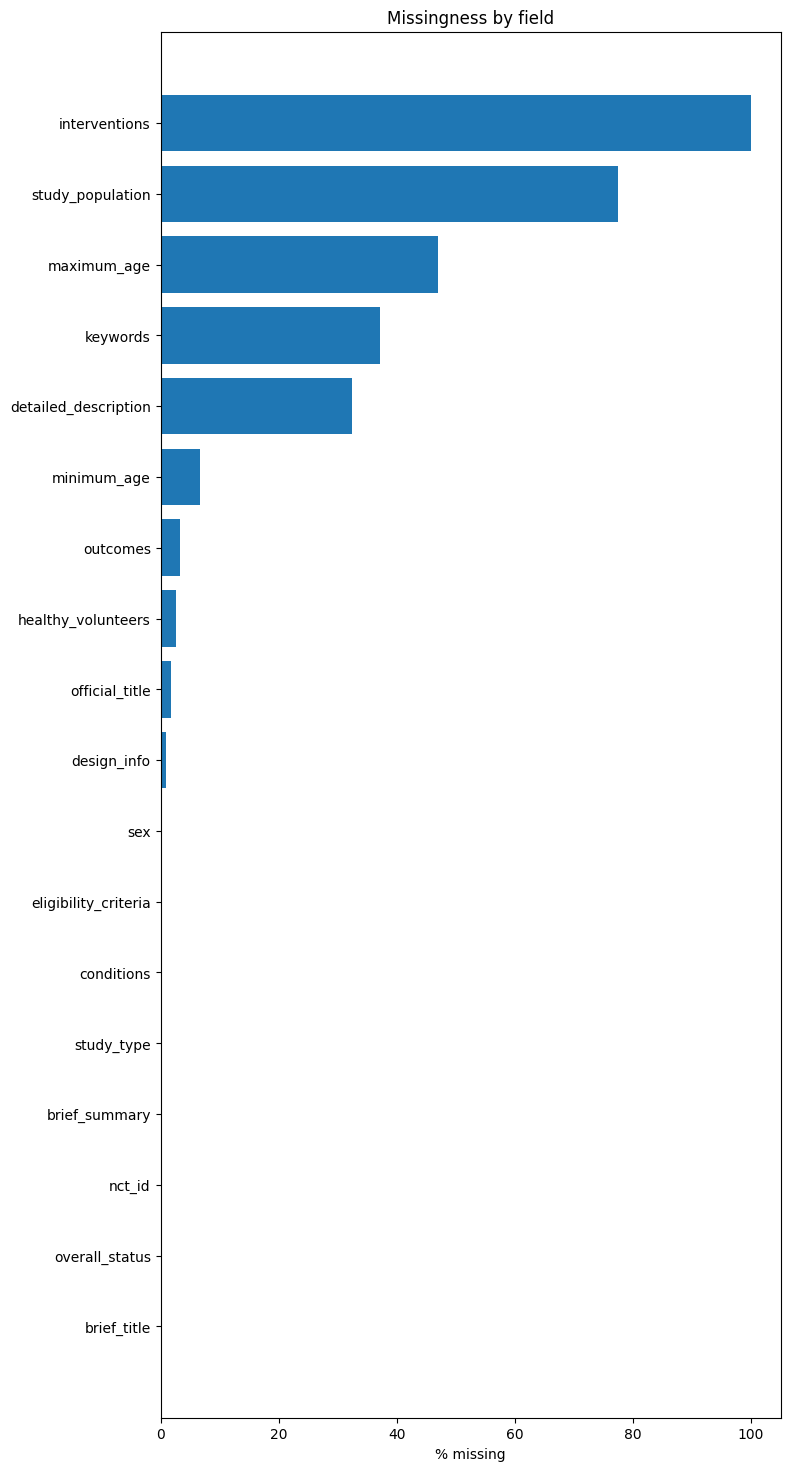

In [10]:
# 3.4 Visualize missingness
plt.figure(figsize=(8, len(missing_df)))
plt.barh(missing_df["field"], missing_df["pct_missing"])
plt.gca().invert_yaxis()
plt.xlabel("% missing")
plt.title("Missingness by field")
plt.show()

Looks like interventions are missing every time, so we will exclude those from our plan. Study_population is also missing a lot but we felt it might give us valuable input when present and might be easy to fill missing values (with something like "general population"; same for maximum age). At the same time keywords are missing too many times so we decided to set them as optional, as it might not be that important for summarization.

In [6]:
# 3.5 drop interventions and keywords
def drop_interventions(row):
    if row["field"] == "interventions":
        row["use"] = "drop"
    return row
def drop_keywords(row):
    if row["field"] == "keywords":
        row["use"] = "optional"
    return row
plan_df.apply(lambda r: drop_interventions(r), axis=1)
plan_df.apply(lambda r: drop_keywords(r), axis=1)
plan_df.to_csv("feature_plan.csv", index=False)


The features **detailed_description** and **brief_summary** will be mandatory in order to compute and evaluate the patient-friendly summary and jargon explanation so we need to drop rows for which these are missing (For us **TAKES 5 MIN TO RUN**)

In [7]:
# 3.6 Must have non-empty detailed_description (primary text) and brief_summary (text used for validating summary)
require_brief_summary = True

primary_text_field = plan_df.query("role == 'primary_text' and use == 'keep'")["field"].iloc[0]
ref_text_field = "brief_summary" if "brief_summary" in dataset.column_names else None

def row_ok(example):
    if is_missing_value(example.get(primary_text_field, None)):
        return False
    if require_brief_summary and ref_text_field and is_missing_value(example.get(ref_text_field, None)):
        return False
    return True

filtered_ds = dataset.filter(row_ok)

print(f"Original rows: {len(dataset):,}")
print(f"Filtered rows: {len(filtered_ds):,}")
print(f"Retained: {100.0*len(filtered_ds)/len(dataset):.2f}%")

# Keep a reference for later steps
work_ds = filtered_ds


Original rows: 541,897
Filtered rows: 366,027
Retained: 67.55%


Let's look again at what features are missing how many entries (For us **TAKES 6 MIN TO RUN**)

In [8]:
candidate_fields_new = [f for f in plan_df.query("use in ['keep']")["field"].tolist()
                    if f in filtered_ds.column_names]


missing_rows = []
N = len(filtered_ds)
for field in candidate_fields_new:
    col = filtered_ds[field]
    miss_cnt = sum(is_missing_value(v) for v in col)
    missing_rows.append({
        "field": field,
        "num_missing": miss_cnt,
        "pct_missing": 100.0 * miss_cnt / N
    })

missing_df_new = pd.DataFrame(missing_rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
missing_df_new

,field,num_missing,pct_missing
0,study_population,282747,77.247580
1,maximum_age,168768,46.108074
2,minimum_age,24940,6.813705
3,outcomes,11696,3.195393
4,healthy_volunteers,8087,2.209400
5,official_title,3261,0.890918
6,design_info,2715,0.741749
7,sex,233,0.063657
8,eligibility_criteria,38,0.010382
9,conditions,12,0.003278


**Decision**: we can eliminate the rows that are missing features up until **outcomes** and fill in missing values for **minimum_age**, **keywords**, **maximum_age**, **study_population**
We decided to fill the values for the rows that have the maximum_age or minimum_age missing in order to not lose more data. For the rows where maximum_age is missing we will fill it with the maximum value for this field. For the rows where minimum_age is missing, we will fill it with value 0 (y/o). We decided to fill the age restrictions like this based on the assumption that if the maximum_age or minimum_age fields were not filled it means that there are no restrictions regarding them.
For the rows that have missing study_population, we still want to keep them, because we consider that where the information exists is of great value. In order to not contradict the eligibility criteria (there can be information about study population, but not represented in this field) and not influence in any manner we will add "no comment" (we will keep this decision in mind in case our model will be heavily influenced by it).

In [9]:
# 3.6 enrich dataset for features "maximum_age", "minimum_age" and "study_population"
max_age_value = max(
    [x for x in filtered_ds["maximum_age"] if x is not None]
)

def fill_missing(example):
    example["maximum_age"] = example["maximum_age"] if example["maximum_age"] is not None else max_age_value
    example["minimum_age"] = example["minimum_age"] if example["minimum_age"] is not None else 0
    example["study_population"] = example["study_population"] if example["study_population"] is not None else "no comment"
    return example

filtered_ds = filtered_ds.map(fill_missing)
work_ds = filtered_ds

**Decision**: Features "outcomes", "healthy_volunteers", "official_title", "design_info", "sex", "eligibility_criteria", "conditions" are missing for few rows so we decided to just drop those rows in order to have consistency.

In [10]:
# 3.7 drop rows in dataset that are missing next fields:
fields_to_check = [
    "outcomes",
    "healthy_volunteers",
    "official_title",
    "design_info",
    "sex",
    "eligibility_criteria",
    "conditions",
]

filtered_ds = filtered_ds.filter(
    lambda example: all(
        example[field] not in [None, ""] for field in fields_to_check
    )
)

In [11]:
work_ds = filtered_ds

In [12]:
# check the changes
candidate_fields_new = [f for f in plan_df.query("use in ['keep']")["field"].tolist()
                    if f in filtered_ds.column_names]


missing_rows = []
N = len(filtered_ds)
for field in candidate_fields_new:
    col = filtered_ds[field]
    miss_cnt = sum(is_missing_value(v) for v in col)
    missing_rows.append({
        "field": field,
        "num_missing": miss_cnt,
        "pct_missing": 100.0 * miss_cnt / N
    })

missing_df_new = pd.DataFrame(missing_rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
missing_df_new

,field,num_missing,pct_missing
0,nct_id,0,0.0
1,detailed_description,0,0.0
2,brief_summary,0,0.0
3,brief_title,0,0.0
4,official_title,0,0.0
5,study_type,0,0.0
6,overall_status,0,0.0
7,conditions,0,0.0
8,minimum_age,0,0.0
9,maximum_age,0,0.0


In [13]:
filtered_ds.save_to_disk("data/filtered_ds")

Saving the dataset (0/6 shards):   0%|          | 0/344475 [00:00<?, ? examples/s]

### Subtask 4: check length of text

Let's look in detail at length of the detailed_description and brief_summary

detailed_description — avg words (sample): 297.9  | median: 194 | max: 5232
brief_summary — avg words (sample): 91.5  | median: 61 | max: 854


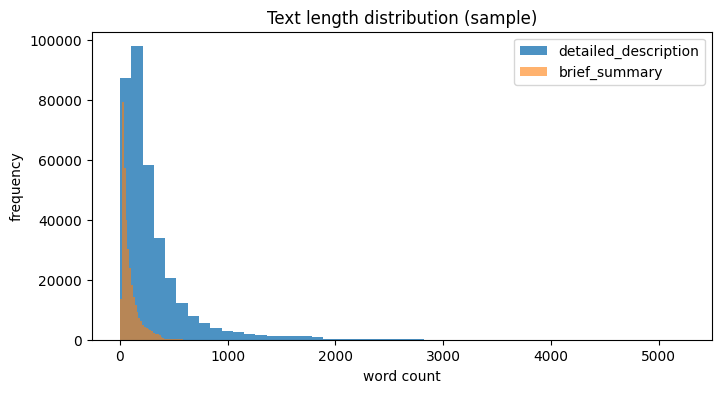

In [18]:
# 4.1 Quick quality spot-check: lengths of primary and reference texts

sample_size = len(work_ds)
sample = work_ds.select(range(sample_size))

primary_lens = [len(t.split()) for t in sample[primary_text_field]]
ref_lens = [len(t.split()) for t in sample[ref_text_field]] if ref_text_field else []

print(f"{primary_text_field} — avg words (sample): {np.mean(primary_lens):.1f}  | median: {np.median(primary_lens):.0f} | max: {np.max(primary_lens):.0f}")
if ref_text_field:
    print(f"{ref_text_field} — avg words (sample): {np.mean(ref_lens):.1f}  | median: {np.median(ref_lens):.0f} | max: {np.max(ref_lens):.0f}")

plt.figure(figsize=(8,4))
plt.hist(primary_lens, bins=50, alpha=0.8, label=primary_text_field)
if ref_text_field:
    plt.hist(ref_lens, bins=50, alpha=0.6, label=ref_text_field)
plt.xlabel("word count")
plt.ylabel("frequency")
plt.title("Text length distribution (sample)")
plt.legend()
plt.show()


The text length is reasonable to work with. We have to think if we need to do anything with the very long ones. We are going to check the exact number of rows that have very long detailed description, in bin sizes of 1000 words.

In [19]:
# 4.2 Check for how many entries are too long

# Define your ranges (in words)
bins = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 6000)]

# Function to count words in each description
def word_count(text):
    if text is None:
        return 0
    return len(str(text).split())

# Count number of examples per bin
counts = []
for lower, upper in bins:
    count = sum(
        1
        for text in filtered_ds["detailed_description"]
        if lower < word_count(text) <= upper
    )
    counts.append((f"{lower}-{upper}", count))

# Print results neatly
for label, count in counts:
    print(f"{label} words: {count}")


0-1000 words: 329545
1000-2000 words: 13272
2000-3000 words: 1101
3000-4000 words: 345
4000-5000 words: 209
5000-6000 words: 3


After checking the length of the detailed description, we can see that there are not a lot of rows that have the detailed description longer than 2000 words. We do not see at this point a problem with the length of this feature, so we decided that we will keep all the rows for now. However, we will have this in mind for later on and will check how the model behaves for the ones with a long description.

By the end of this part we have a filtered and augmented dataset "filtered_ds" to work with in the beginning of Phase 3

## Part 2: Find suitable metrics

### Subtask 5: Readability metrics

In order to validate the summarization part we will check the summary is in the “who/what/why/how” format and also use the reference field "brief_summary" to check for similarity. The problem is for the simplification part.

We found the library "textstat" to calculate readability and complexity of a text: https://www.kaggle.com/code/yhirakawa/textstat-how-to-evaluate-readability but we need to **check if our text is indeed hard** to read and understand. We will calculate the first 4 metrics presented in the documentation. (For us **TAKES 7 MIN TO RUN**)

In [20]:
# 5.1 Readability (Flesch–Kincaid, gunning_fog, smog_index, flesch_reading_ease) using textstat
import textstat

def readability_metrics(text: str):
    return {
        "fk_grade": textstat.flesch_kincaid_grade(text),
        "gunning_fog": textstat.gunning_fog(text),
        "smog_index": textstat.smog_index(text),
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
    }

text_fields = [primary_text_field, ref_text_field]

# Compute readability on a smaller sample for speed
read_sample_size = min(5000, sample_size)
read_rows = []
for i in range(read_sample_size):
    rr = {"idx": i}
    for f in text_fields:
        t = sample[f][i]
        rr.update({f"{f}__{k}": v for k, v in readability_metrics(t).items()})
    read_rows.append(rr)

read_df = pd.DataFrame(read_rows)

# Summaries
read_summ_rows = []
for f in text_fields:
    sub = read_df[[c for c in read_df.columns if c.startswith(f"{f}__")]]
    read_summ_rows.append({
        "field": f,
        "fk_grade_mean": np.nanmean(sub[f"{f}__fk_grade"]),
        "gunning_fog_mean": np.nanmean(sub[f"{f}__gunning_fog"]),
        "smog_index_mean": np.nanmean(sub[f"{f}__smog_index"]),
        "flesch_reading_ease_mean": np.nanmean(sub[f"{f}__flesch_reading_ease"]),
    })
readability_summary_df = pd.DataFrame(read_summ_rows)
readability_summary_df


,field,fk_grade_mean,gunning_fog_mean,smog_index_mean,flesch_reading_ease_mean
0,detailed_description,15.627777,18.855860,16.550242,24.440275
1,brief_summary,17.174619,20.347851,17.438016,18.220449


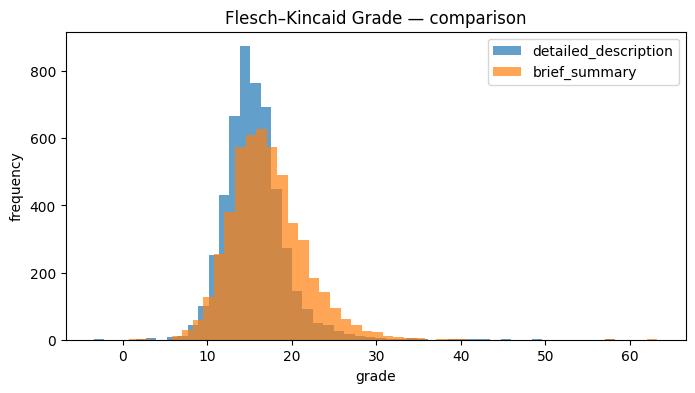

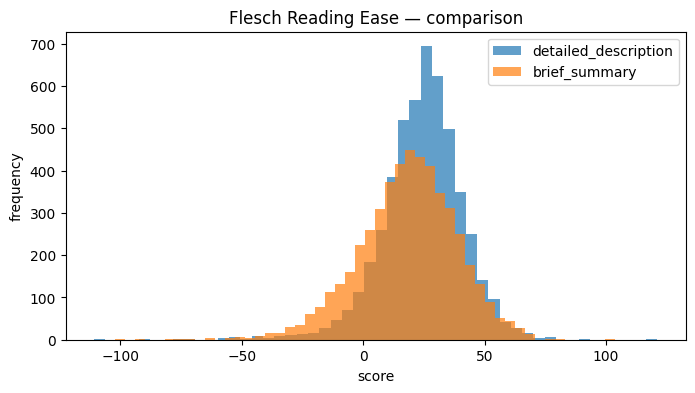

In [21]:
# 5.2 Compare readability distributions
if ref_text_field:
    plt.figure(figsize=(8,4))
    plt.hist(read_df[f"{primary_text_field}__fk_grade"], bins=50, alpha=0.7, label=primary_text_field)
    plt.hist(read_df[f"{ref_text_field}__fk_grade"], bins=50, alpha=0.7, label=ref_text_field)
    plt.title("Flesch–Kincaid Grade — comparison")
    plt.xlabel("grade"); plt.ylabel("frequency"); plt.legend(); plt.show()

    plt.figure(figsize=(8,4))
    plt.hist(read_df[f"{primary_text_field}__flesch_reading_ease"], bins=50, alpha=0.7, label=primary_text_field)
    plt.hist(read_df[f"{ref_text_field}__flesch_reading_ease"], bins=50, alpha=0.7, label=ref_text_field)
    plt.title("Flesch Reading Ease — comparison")
    plt.xlabel("score"); plt.ylabel("frequency"); plt.legend(); plt.show()


Our theory was correct the text is hard to read and understand. We can also see that the brief summary is more distributed. We will use this metrics in the loss function of the simplification model. There is one more task we want to sustain: jargon explanation. Let's look at exactly how much jargon we have there.

### Subtask 6: Jargon density

This is a initial, very naive way to calculate jargon, based on a manual definition of what jargon is.

In [22]:
import spacy
nlp = spacy.load("en_core_web_sm")
def iter_docs(texts, batch_size=64):
    for doc in nlp.pipe(texts, batch_size=batch_size, disable=[]):
        yield doc
tok_sample_size = min(2000, len(work_ds))
tok_sample = work_ds.select(range(tok_sample_size))

In [24]:
# 6.1 Manual define what jargon is (rarity, suffixes and substrings) and calculate density (without stop-words)
biomed_suffixes = (
    "itis","emia","osis","otomy","ectomy","algia","pathy","oma","genic","genic","phage",
    "phagia","pharm","lysis","cardio","neuro","hepato","derm","pulmo","renal","oncol",
    "immuno","therap","toxic","metabol","genom","nephro","hemo","hema","gastro","neuro",
    "ophthal","otol","psycho","endo","osteo","myo","hepatic","pulmonary","renal"
)
biomed_substrings = (
    "placebo","randomiz","double-blind","intervention","biomarker","chemother","radiother",
    "metast","carcin","tumor","oncolog","immun", "biologic","antibody","mg","ml","dose","dosing",
    "adverse","endpoint","efficacy","safety"
)

# Build doc frequency for non-stopword alphabetic lemmas in primary_text_field
docs_nonstop = []
for doc in iter_docs([t for t in tok_sample[primary_text_field]]):
    lemmas = set([t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop])
    docs_nonstop.append(lemmas)

from collections import Counter
df_counter = Counter()
for lemmas in docs_nonstop:
    df_counter.update(lemmas)

num_docs = len(docs_nonstop)
def doc_freq(token_lemma):
    return df_counter[token_lemma] / max(1, num_docs)

def looks_jargony(tok: str) -> bool:
    if len(tok) >= 3 and tok.isupper():  # acronym
        return True
    if any(tok.endswith(suf) for suf in biomed_suffixes):
        return True
    if any(sub in tok for sub in biomed_substrings):
        return True
    if "-" in tok and len(tok) > 6:
        return True
    return False

# Classify tokens & compute jargon density per doc (primary_text_field)
jargon_threshold = 0.01  # tokens appearing in <=1% of docs are considered rare
jargon_examples = Counter()

jargon_density_list = []
for doc in iter_docs([t for t in tok_sample[primary_text_field]]):
    content = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
    if not content:
        jargon_density_list.append(0.0); continue
    jargon_tokens = [
        w for w in content
        if (doc_freq(w) <= jargon_threshold) or looks_jargony(w)
    ]
    jargon_density = len(jargon_tokens) / max(1, len(content))
    jargon_density_list.append(jargon_density)
    jargon_examples.update(jargon_tokens)

jargon_density_arr = np.array(jargon_density_list)
print(f"Jargon density — mean: {np.mean(jargon_density_arr):.3f} | median: {np.median(jargon_density_arr):.3f}")


Jargon density — mean: 0.268 | median: 0.265


In [25]:
# Show top-25 "jargon" tokens (by frequency under the above heuristic)
top_jargon = pd.DataFrame(jargon_examples.most_common(25), columns=["token","count"])
top_jargon

,token,count
0,intervention,1275
1,dose,1127
2,analysis,704
3,randomize,685
4,mg,622
5,safety,612
6,efficacy,499
7,tumor,421
8,placebo,406
9,adverse,297


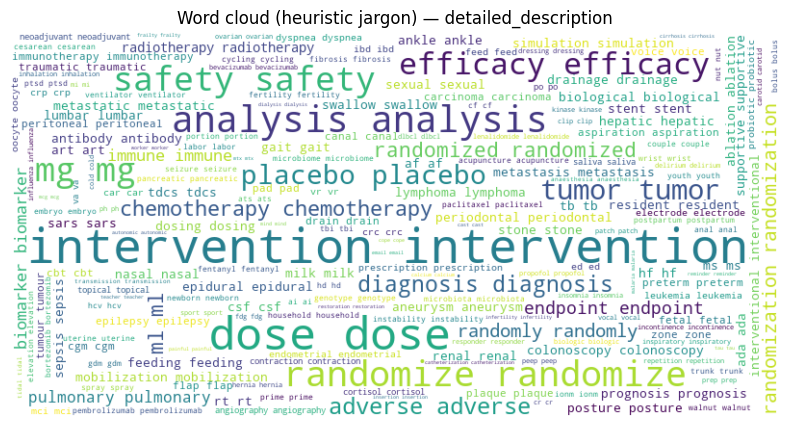

In [26]:
# 6.2 Show a word cloud of all jargon words
from wordcloud import WordCloud
def show_wordcloud_from_counter(counter, title):
    # Build a single string by repeating tokens by frequency
    text = " ".join([tok for tok, cnt in counter.items() for _ in range(cnt)])
    if not text.strip():
        print(f"(empty wordcloud for {title})")
        return
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

jargon_wc_counter = Counter({tok: cnt for tok, cnt in jargon_examples.items() if cnt >= 5})
show_wordcloud_from_counter(jargon_wc_counter, f"Word cloud (heuristic jargon) — {primary_text_field}")


We didn't really liked this method of finding jargon words so after more debating and office hours we found the next ideas.

We could use a simple english metric to identify and measure the jargons. Below is a piece of code to identify the technical terms (as of now, it only considers a small amount of words).
There is also a much better metric ( "wordfreq" ) to enhance it, the implementation for the same is two cells down.

In [28]:
# 6.3 Simple english metric
import re
from collections import Counter

# Extract the 'detailed_description' column
texts = [str(x) for x in work_ds["detailed_description"] if x is not None]

# Tokenize the text
def tokenize(text):
    return re.findall(r"\b[a-zA-Z][a-zA-Z\-]+\b", text.lower())

all_words = []
for text in texts:
    all_words.extend(tokenize(text))

# Load a simple English word list
def load_common_words():
    # TODO: replace with larger list if available ( added a baseline for testing now)
    common_words = set("""
    a about above after again against all am an and any are aren't as at be because been before
    being below between both but by can can't come could couldn't did didn't do does doesn't doing
    don't down during each few for from further had hadn't has hasn't have haven't having he he'd
    he'll he's her here here's hers herself him himself his how how's i i'd i'll i'm i've if in into
    is isn't it it's its itself just know like make many me might more most must my myself no nor not
    of off on once only or other our ours ourselves out over own said same see should shouldn't so
    some such take than that that's the their theirs them themselves then there there's these they
    they'd they'll they're they've this those through to too under until up very was wasn't we we'd
    we'll we're we've were weren't what what's when when's where where's which while who who's whom
    why why's with won't would wouldn't you you'd you'll you're you've your yours yourself yourselves
    """.split())
    return common_words

common_words = load_common_words()

# Identify uncommon (technical/jargon) words
def identify_jargon(words, common_words, min_len=4):
    return Counter([w for w in words if w not in common_words and len(w) >= min_len])

jargon_counts = identify_jargon(all_words, common_words)

# Compute Simple English Metric
def simple_english_metric(total_words, jargon_count):
    return round((jargon_count / total_words) * 100, 2)

metric = simple_english_metric(len(all_words), len(jargon_counts))

# Display results
print(f"Total words: {len(all_words)}")
print(f"Unique jargon terms: {len(jargon_counts)}")
print(f"Simple English Metric: {metric}% jargon\n")

print(f"{'Term':<25} {'Count':>6}")
print("-" * 35)
for term, count in jargon_counts.most_common(100):  # Top 100 jargon terms
    print(f"{term:<25} {count:>6}")

Total words: 96994533
Unique jargon terms: 446011
Simple English Metric: 0.46% jargon

Term                       Count
-----------------------------------
will                      1759957
study                     821989
patients                  817625
treatment                 425053
group                     281150
participants              260907
clinical                  235681
data                      227264
patient                   213532
using                     199905
intervention              185524
blood                     175013
used                      165067
subjects                  162767
disease                   162424
care                      158468
months                    157613
weeks                     155495
therapy                   153975
days                      151339
also                      151149
time                      150551
receive                   149952
pain                      148315
health                    143297
dose              

Implementation using "wordfreq"

In [29]:
# 6.4 Identify jargon using wordfreq

from wordfreq import zipf_frequency
import re
from collections import Counter

# Extract 'detailed_description' column
texts = [str(x) for x in work_ds["detailed_description"] if x is not None]

# Tokenize text
def tokenize(text):
    return re.findall(r"\b[a-zA-Z][a-zA-Z\-]+\b", text.lower())

all_words = []
for text in texts:
    all_words.extend(tokenize(text))

print(f"Total words extracted: {len(all_words)}")

# Determine which words are common using wordfreq
def is_common_word(word, threshold=4.5):
    """
    Uses Zipf frequency (log scale from 0–7):
    - ~7 = very common (e.g., 'the')
    - ~4–5 = common everyday English
    - <4 = rare/technical terms
    """
    return zipf_frequency(word, "en") >= threshold

# Identify jargon
def identify_jargon(words, threshold=4.5, min_len=4):
    jargon = [w for w in words if len(w) >= min_len and not is_common_word(w, threshold)]
    return Counter(jargon)

jargon_counts = identify_jargon(all_words, threshold=4.5)

# Compute Simple English Metric
def simple_english_metric(total_words, jargon_count):
    if total_words == 0:
        return 0
    return round((jargon_count / total_words) * 100, 2)

metric = simple_english_metric(len(all_words), len(jargon_counts))

# Display results
print("\n=== Simple English Jargon Analysis ===")
print(f"Unique jargon terms: {len(jargon_counts)}")
print(f"Simple English Metric: {metric}% jargon\n")

print(f"{'Term':<25} {'Count':>6}")
print("-" * 35)
for term, count in jargon_counts.most_common(100):
    print(f"{term:<25} {count:>6}")

Total words extracted: 96994533

=== Simple English Jargon Analysis ===
Unique jargon terms: 421142
Simple English Metric: 0.43% jargon

Term                       Count
-----------------------------------
participants              260907
intervention              185524
subjects                  162767
dose                      142969
randomized                140895
investigators             114769
evaluate                  100721
baseline                   95267
outcomes                   94735
assess                     85680
efficacy                   84148
assessment                 82250
criteria                   77331
symptoms                   76606
outcome                    72440
consent                    64678
placebo                    63487
procedure                  58592
chronic                    58404
assessed                   58380
evaluation                 57985
participant                57519
objective                  57119
measured                   57059
pr

This "wordfreq" implementation seems to be working good so we will use it for the first experiments in jargon identification. We might need to play around with the threshold under which a word is considered "jargon" but we will see during P3. (We might also need to focus more on "medical jargon" rather than just plain rare words, but we need to see results of first experiments in P3 for this)

By the end of this notebook we:
- have a functional filtered and augmented dataset to work with in the start of P3
- decided on which metrics to use for summarization, simplification, jargon identification

### Part 3 - Summarization training - Trial - Milestone 3
In this part we present a trial for training a summarization model using the existing brief_summary field. We wanted to train our own transformer using a pretrained model. We hoped that, given a pretrained model, it would learn more from the entire trial, and won't just replicate the brief_summary (which was often too technical or too short).

In [25]:
from datasets import load_from_disk
import re
import unicodedata
import torch
import matplotlib.pyplot as plt
import copy
import itertools
from torch.optim import AdamW
import numpy as np
import textstat
from wordfreq import zipf_frequency
from collections import Counter
from typing import Dict, List
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from datasets import load_dataset
from evaluate import load
from tqdm import tqdm


Let's load the filtered dataset we created during the milestone 2

In [1]:
from datasets import load_from_disk

full_ds = load_from_disk("data/filtered_ds")

# Use 2000 for training on CPU; adjust if needed
subset_size = 2000
ds = full_ds.shuffle(seed=42).select(range(subset_size))

print("Loaded dataset with", len(ds), "rows")

C:\Users\Flaviu\miniconda3\envs\nlp\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Loaded dataset with 2000 rows


We apply light, meaning-preserving preprocessing before training. Each text field (detailed description, brief summary, eligibility criteria) is normalized for Unicode, HTML tags are removed, and whitespace is collapsed. We do not remove stopwords because transformer-based seq2seq models rely on the full syntactic structure to understand negation and eligibility phrasing. To respect model context limits, we truncate inputs at sentence boundaries where possible.

In [2]:

# Preprocessing for T5
# Transformer seq2seq models (T5/FLAN-T5) benefit from clean, meaning-preserving inputs.
# Doing light normalization: remove HTML, collapse whitespace, fix newlines, normalize unicode.
# And ,not removing stopwords: removing them can break syntax and change meaning

import re
import unicodedata

def clean_text(text: str) -> str:
    if text is None:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def safe_truncate(text: str, max_chars: int = 4000) -> str:
    if len(text) <= max_chars:
        return text
    # try to cut at last sentence end
    chunk = text[:max_chars]
    idx = chunk.rfind(". ")
    if idx != -1:
        return chunk[:idx+1]
    return chunk  # fallback

def build_input(example):
    desc = clean_text(example.get("detailed_description", ""))
    brief = clean_text(example.get("brief_summary", ""))
    elig = clean_text(example.get("eligibility_criteria", ""))

    combined = f"""
    Summarize the following clinical trial in 3–4 patient-friendly sentences.

    Detailed Description:
    {desc}

    Brief Summary:
    {brief}

    Eligibility Criteria:
    {elig}
    """

    combined = safe_truncate(combined, 4000)

    example["input_text"] = combined
    example["target_text"] = brief  # model learns from original brief summary
    return example

ds = ds.map(build_input)
print("Preprocessing complete!")



Preprocessing complete!


Using google/flan-t5-small for faster processing

In [3]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name_summarization = "google/flan-t5-small"

tokenizer_summarization = AutoTokenizer.from_pretrained(model_name_summarization)
model_summarization = AutoModelForSeq2SeqLM.from_pretrained(model_name_summarization)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_summarization.to(device)

print("Using device:", device)

Using device: cuda


In [4]:
# Tokenization
max_input_len = 512
max_target_len = 128

def tokenize_batch(batch):
    inputs = tokenizer_summarization(
        batch["input_text"],
        padding="max_length",
        truncation=True,
        max_length=max_input_len,
    )
    targets = tokenizer_summarization(
        batch["target_text"],
        padding="max_length",
        truncation=True,
        max_length=max_target_len,
    )
    inputs["labels"] = targets["input_ids"]
    return inputs

tokenized_ds_summarization = ds.map(
    tokenize_batch,
    batched=True,
    remove_columns=ds.column_names
)

tokenized_ds_summarization = tokenized_ds_summarization.train_test_split(test_size=0.1)
train_ds_summarization = tokenized_ds_summarization["train"]
val_ds_summarization = tokenized_ds_summarization["test"]

print(train_ds_summarization, val_ds_summarization)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1800
}) Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 200
})


In [5]:
# Arguments for training
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer

data_collator_summarization = DataCollatorForSeq2Seq(tokenizer_summarization, model=model_summarization)

training_args_summarization = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_small_ct_model",
    save_strategy="epoch",        # we still save each epoch
    eval_strategy="steps",
    eval_steps=50,
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    predict_with_generate=True,
    fp16=False,
)

In [6]:
# Trainer and train
trainer_summarization = Seq2SeqTrainer(
    model=model_summarization,
    args=training_args_summarization,
    processing_class=tokenizer_summarization,
    data_collator=data_collator_summarization,
    train_dataset=train_ds_summarization,
    eval_dataset=val_ds_summarization,
)
trainer_summarization.train()

Step,Training Loss,Validation Loss
50,10.931200,5.835440
100,4.762300,2.742819
150,2.669100,2.099049
200,2.159100,1.814501
250,1.900800,1.636385
300,1.719100,1.481271
350,1.606100,1.350330
400,1.553500,1.244085
450,1.459500,1.164270
500,1.319200,1.102505


TrainOutput(global_step=675, training_loss=2.552785924275716, metrics={'train_runtime': 223.0852, 'train_samples_per_second': 24.206, 'train_steps_per_second': 3.026, 'total_flos': 1003808725401600.0, 'train_loss': 2.552785924275716, 'epoch': 3.0})

Let's do a short evaluation using rouge, which is a common metric in text summarization.

In [12]:
from evaluate import load
from tqdm import tqdm
import torch

def rouge_summary_eval():
    rouge = load("rouge")
    preds, refs = [], []

    for ex in tqdm(val_ds_summarization, total=len(val_ds_summarization)):

        input_ids = torch.tensor(ex["input_ids"]).unsqueeze(0).to(model_summarization.device)
        attention_mask = torch.tensor(ex["attention_mask"]).unsqueeze(0).to(model_summarization.device)

        with torch.no_grad():
            out_ids = model_summarization.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=128,
            )

        pred = tokenizer_summarization.decode(out_ids[0], skip_special_tokens=True)

        labels = ex["labels"]
        labels = [t if t != -100 else tokenizer_summarization.pad_token_id for t in labels]
        ref = tokenizer_summarization.decode(labels, skip_special_tokens=True)

        preds.append(pred)
        refs.append(ref)

    results = rouge.compute(predictions=preds, references=refs)
    print(results)

rouge_summary_eval()


100%|██████████| 200/200 [03:47<00:00,  1.14s/it]


{'rouge1': np.float64(0.6438501409990934), 'rouge2': np.float64(0.5933637623343545), 'rougeL': np.float64(0.6259974594474484), 'rougeLsum': np.float64(0.627868930655948)}


Let's look at an example of the created summarization, did in manage to learn more information from the entire trial, or is it just replicating the brief_summary?

In [17]:
#Inference Function
def summarize_trial(text):
    cleaned = clean_text(text)
    prompt = "Summarize the following clinical trial:\n\n" + cleaned

    inputs = tokenizer_summarization(prompt, return_tensors="pt",
                       truncation=True, max_length=512).to(device)

    output = model_summarization.generate(
        **inputs,
        max_length=150,
        num_beams=4
    )
    return tokenizer_summarization.decode(output[0], skip_special_tokens=True)

# Test inference
print(ds[0]["brief_summary"])
print("----------------")
print(summarize_trial(ds[0]["input_text"]))

Bevacizumab is an angiogenesis inhibitor which means it works to stop blood vessel formation in tumors. Without new blood vessels, the growth of a tumor is slowed. Chemotherapy drugs kill cancer cells more directly. This study will evaluate:

* How bevacizumab, given with chemotherapy before surgery, and then bevacizumab given alone after surgery, will affect locally advanced breast tumors
* Side effects from adding bevacizumab to chemotherapy
* Whether adding bevacizumab to chemotherapy for breast cancer will affect the heart
* If receiving bevacizumab will have any effect on how patients recover from surgery
* Side effects of the combinations of drugs used in this study
----------------
Bevacizumab is an angiogenesis inhibitor which means it works to stop blood vessel formation in tumors. Without new blood vessels, the growth of a tumor is slowed. Chemotherapy drugs kill cancer cells more directly.


Unfortunately, our fears came true, and the model is not able to learn more information and context. We would argue that the architecture is too powerful and the model is loyally predicting the gold targets. Lowering the model architecture would not be the solution because then the model would not be able to generate coherent and understandable summary. The problem lies with chosing the brief summary as gold target. We will come back later on how to address this

### Part 4 - Simplification Training - Trial - Milestone 3

The problem with the simplification step, was that we didn't even have any gold target to use, so we had to find the solution in something else. After a long research and documentation, we found the dataset GEM/cochrane-simplification https://huggingface.co/datasets/GEM/cochrane-simplification which could be a solution to our exact problem. It contains medical text before and after simplification "Cochrane is an English dataset for paragraph-level simplification of medical texts". It seemed like we at least be successful with the simplification step.

In [1]:
from datasets import load_dataset

cochrane_ds = load_dataset("GEM/cochrane-simplification", trust_remote_code=True)

# # Apply shuffle + select to each split
# cochrane_small = {
#     split: ds.shuffle(seed=42).select(range(100))
#     for split, ds in cochrane_ds.items()
# }
#
# # Convert back to DatasetDict (optional but cleaner)
# from datasets import DatasetDict
# cochrane_ds = DatasetDict(cochrane_small)

print(cochrane_ds["train"][0])
print(len(cochrane_ds["train"]))

C:\Users\Flaviu\miniconda3\envs\nlp\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'GEM/cochrane-simplification' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Using the latest cached version of the dataset since GEM/cochrane-simplification couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'cochrane-simplification' at C:\Users\Flaviu\.cache\huggingface\datasets\GEM___cochrane-simplification\cochrane-simplification\1.0.0\fd871e1bc42b6d9310e70d5667d5e874ed27d4ea7a6367f8042f1a2573deb2dd (last modified on Mon Dec 15 14:32:45 2025).


{'gem_id': 'cochrane-simplification-train-0', 'gem_parent_id': 'cochrane-simplification-train-0', 'source': 'Two trials met the inclusion criteria. One compared 2% ketanserin ointment in polyethylene glycol (PEG) with PEG alone, used twice a day by 40 participants with arterial leg ulcers, for eight weeks or until healing, whichever was sooner. One compared topical application of blood-derived concentrated growth factor (CGF) with standard dressing (polyurethane film or foam); both applied weekly for six weeks by 61 participants with non-healing ulcers (venous, diabetic arterial, neuropathic, traumatic, or vasculitic). Both trials were small, reported results inadequately, and were of low methodological quality. Short follow-up times (six and eight weeks) meant it would be difficult to capture sufficient healing events to allow us to make comparisons between treatments. One trial demonstrated accelerated wound healing in the ketanserin group compared with the control group. In the tria

We initially tried a t5-small model, but it was performing very poorly, generating at some point the same word over and over again, so we decided to try t5-base, which was more computationally expensive but hopefully would give better results.

In [2]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
model_name_simplification = "t5-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

tokenizer_simplification = AutoTokenizer.from_pretrained(model_name_simplification)
model_simplification = AutoModelForSeq2SeqLM.from_pretrained(model_name_simplification).to(device)


cuda


Let's define the metrics we talked during milestone 2. We use flesch_kincaid_grade, gunning_fog, smog_index, flesch_reading_ease, and jargon_ratio to assess if the simplified text is indeed easier to understand than the initial one.

In [2]:
import numpy as np
import textstat
from wordfreq import zipf_frequency
import re
from collections import Counter
from typing import Dict, List
import evaluate

def readability_metrics(text: str) -> Dict[str, float]:
    """Compute basic readability metrics for a text."""
    return {
        "fk_grade": textstat.flesch_kincaid_grade(text),
        "gunning_fog": textstat.gunning_fog(text),
        "smog_index": textstat.smog_index(text),
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
    }


def tokenize_words(text: str) -> List[str]:
    return re.findall(r"\b[a-zA-Z][a-zA-Z\-]+\b", text.lower())


def is_common_word(word: str, threshold: float = 4.5) -> bool:
    """
    Uses Zipf frequency (0–7, higher = more common).
    ~4–5: common everyday English; <4: rare/technical.
    """
    return zipf_frequency(word, "en") >= threshold


def jargon_ratio(text: str, threshold: float = 4.5, min_len: int = 4) -> float:
    """
    Approximate jargon density using wordfreq.
    Returns % of tokens considered jargon.
    """
    words = tokenize_words(text)
    if not words:
        return 0.0
    jargon_words = [
        w for w in words
        if len(w) >= min_len and not is_common_word(w, threshold)
    ]
    return 100.0 * len(jargon_words) / len(words)


Let's tokenize the input, taking it through a preprocess function first

In [4]:
max_input_length = 256
max_target_length = 128

def preprocess_function(batch):
    inputs = []
    for src in batch["source"]:
        # Instruction-style prefix; you can tune wording
        inputs.append(f"simplify for better reading and understanding: {src}")

    model_inputs = tokenizer_simplification(
        inputs,
        max_length=max_input_length,
        truncation=True,
        padding="max_length",
    )

    with tokenizer_simplification.as_target_tokenizer():
        labels = tokenizer_simplification(
            batch["target"],
            max_length=max_target_length,
            truncation=True,
            padding="max_length",
        )["input_ids"]

    model_inputs["labels"] = labels
    return model_inputs

tokenized_simpl_ds_simplification = cochrane_ds.map(
    preprocess_function,
    batched=True,
    remove_columns=cochrane_ds["train"].column_names,
)
tokenized_simpl_ds_simplification


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

C:\Users\Flaviu\miniconda3\envs\nlp\Lib\site-packages\transformers\tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3568
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 411
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 480
    })
})

We aggregate all the readability metrics in order to compute them after each epoch of training.

In [5]:
# ROUGE for overlap with reference simplifications
rouge = evaluate.load("rouge")


def postprocess_text(preds, labels):
    preds = [p.strip() for p in preds]
    labels = [l.strip() for l in labels]
    return preds, labels


def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Replace -100 (ignore index) with tokenizer.pad_token_id
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer_simplification.batch_decode(preds, skip_special_tokens=True)

    # For labels we need to remove ignored index (-100)
    labels = np.where(labels != -100, labels, tokenizer_simplification.pad_token_id)
    decoded_labels = tokenizer_simplification.batch_decode(labels, skip_special_tokens=True)

    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    # ROUGE
    rouge_result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )

    # Readability & jargon – average over batch
    fk_grades = []
    fre_scores = []
    jargon_ratios = []

    for text in decoded_preds:
        rm = readability_metrics(text)
        fk_grades.append(rm["fk_grade"])
        fre_scores.append(rm["flesch_reading_ease"])
        jargon_ratios.append(jargon_ratio(text))

    metrics = {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"],
        "fk_grade_pred": float(np.nanmean(fk_grades)),
        "fre_pred": float(np.nanmean(fre_scores)),
        "jargon_pct_pred": float(np.nanmean(jargon_ratios)),
    }

    # Higher Flesch reading ease is better, lower FK grade & jargon_pct ideally
    return metrics


Let's define the the arguments for the training

In [6]:
output_dir = "./t5-simplification-cochrane"

batch_size = 4  # adjust to your GPU
num_train_epochs = 2

args_simplification = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=8e-4,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=num_train_epochs,
    predict_with_generate=True,
    logging_strategy="steps",
    logging_steps=1,
    report_to=["none"],  # or ["tensorboard"]
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",  # you could also define a custom composite metric offline
    fp16=True,
)

data_collator_simplification = DataCollatorForSeq2Seq(tokenizer_simplification, model=model_simplification)

trainer_simplification = Seq2SeqTrainer(
    model=model_simplification,
    args=args_simplification,
    train_dataset=tokenized_simpl_ds_simplification["train"],
    eval_dataset=tokenized_simpl_ds_simplification["validation"],
    tokenizer=tokenizer_simplification,
    data_collator=data_collator_simplification,
    compute_metrics=compute_metrics,
)

C:\Users\Flaviu\AppData\Local\Temp\ipykernel_24292\3799267751.py:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer_simplification = Seq2SeqTrainer(


In order to maximize the performance, we also conducted a learning rate finder experiment. We started with a very low learning rate and steadily increased it to a given point. Then we need to look at the plot of the loss and pick the learning rate where the plot looks the steepest, which is usually 10 steps before the lowest loss.

Step 10/100 - lr=3.98e-07 - loss=5.4746
Step 20/100 - lr=1.58e-06 - loss=5.5034
Step 30/100 - lr=6.31e-06 - loss=5.3373
Step 40/100 - lr=2.51e-05 - loss=5.1590
Step 50/100 - lr=1.00e-04 - loss=5.0603
Step 60/100 - lr=3.98e-04 - loss=4.3000
Step 70/100 - lr=1.58e-03 - loss=3.7746
Step 80/100 - lr=6.31e-03 - loss=3.4422
Step 90/100 - lr=2.51e-02 - loss=3.7375
Step 100/100 - lr=1.00e-01 - loss=5.5767


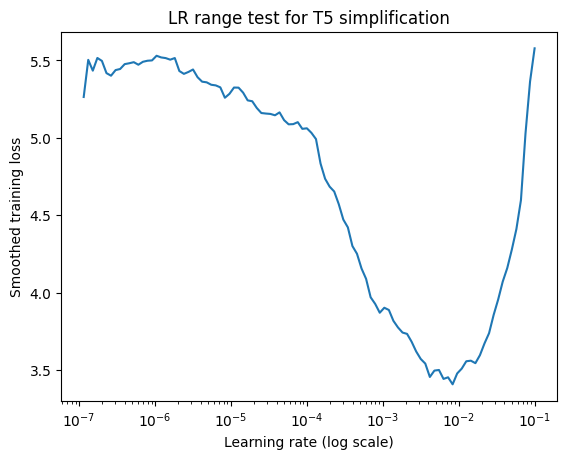

Minimum-loss LR ~ 8.32e-03
Suggested LR (10x smaller) ~ 8.32e-04


In [11]:
#LR Finder
import copy
import itertools
from torch.optim import AdamW


def lr_range_test(
    trainer,
    start_lr: float = 1e-7,
    end_lr: float = 1.0,
    num_iter: int = 100,
    smoothing: float = 0.05,
    diverge_factor: float = 4.0,
):
    """
    Run a Leslie Smith-style LR range test on the Hugging Face Trainer.

    - Increases LR exponentially from start_lr to end_lr over num_iter steps.
    - Uses a small subset of the training data.
    - Returns lrs and smoothed losses WITHOUT permanently changing your model.
    """
    model = trainer.model

    # Save original weights so we can restore them afterwards
    original_state = copy.deepcopy(model.state_dict())

    # Build a fresh optimizer with the starting LR
    optimizer = AdamW(model.parameters(), lr=start_lr)

    # Use Trainer's dataloader so we respect its collator, sampling, etc.
    train_dataloader = trainer.get_train_dataloader()
    device = model.device

    # Exponential LR schedule
    lr_mult = (end_lr / start_lr) ** (1 / num_iter)
    lr = start_lr

    lrs = []
    losses = []

    best_loss = float("inf")
    avg_loss = 0.0

    model.train()

    for step, batch in enumerate(itertools.islice(train_dataloader, num_iter)):
        # Prepare inputs the same way Trainer does (handles device placement, labels, etc.)
        batch = trainer._prepare_inputs(batch)

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        # Update learning rate
        lr *= lr_mult
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        # Record & smooth loss
        loss_val = loss.item()
        if step == 0:
            avg_loss = loss_val
        else:
            avg_loss = smoothing * loss_val + (1 - smoothing) * avg_loss

        lrs.append(lr)
        losses.append(avg_loss)

        # Track best loss and stop early if we diverge
        if avg_loss < best_loss:
            best_loss = avg_loss

        if avg_loss > diverge_factor * best_loss:
            print(f"Stopping early at step {step} (loss diverged).")
            break

        if (step + 1) % 10 == 0:
            print(f"Step {step+1}/{num_iter} - lr={lr:.2e} - loss={avg_loss:.4f}")

    # Restore original weights
    model.load_state_dict(original_state)

    return np.array(lrs), np.array(losses)

# Temporarily comment out the actual training while you run the LR finder:
# trainer.train()
import matplotlib.pyplot as plt
lrs, losses = lr_range_test(
    trainer_simplification,
    start_lr=1e-7,
    end_lr=1e-1,
    num_iter=100,
)

plt.figure()
plt.plot(lrs, losses)
plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Smoothed training loss")
plt.title("LR range test for T5 simplification")
plt.show()

best_lr_idx = np.argmin(losses)
best_lr = lrs[best_lr_idx]
print(f"Minimum-loss LR ~ {best_lr:.2e}")
print(f'Suggested LR (10x smaller) ~ {best_lr/10:.2e}')


We found the suggested learning rate 8e-04 and put it in the arguments. Now let's train our simplification model.

In [7]:
trainer_simplification.train()

# Save final model + tokenizer
trainer_simplification.save_model(output_dir)
tokenizer_simplification.save_pretrained(output_dir)

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Fk Grade Pred,Fre Pred,Jargon Pct Pred
1,2.266700,2.128437,0.177593,0.064178,0.143877,8.837095,52.814745,23.317138
2,1.987200,2.064683,0.171029,0.054329,0.135815,9.324226,51.637842,23.457852


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


('./t5-simplification-cochrane\\tokenizer_config.json',
 './t5-simplification-cochrane\\special_tokens_map.json',
 './t5-simplification-cochrane\\spiece.model',
 './t5-simplification-cochrane\\added_tokens.json',
 './t5-simplification-cochrane\\tokenizer.json')

The training doesn't look very promising, we expected a more significant drop from epoch 1 to epoch 2. The usual training time was 2-3 hours for 2-3 epochs, the last train shows 9 minutes because of some caching. We tried to even let it run for 5 epochs, but the loss would flatten after only 2 epochs so we considered to stick with that.

Let's apply this model to our brief_summary and see how it is performing.

In [3]:
# Load your clinical dataset (already preprocessed in Part 1)
# Make sure this path matches where you saved filtered_ds / work_ds
from datasets import load_from_disk
clinical_ds = load_from_disk("data/filtered_ds")
clinical_ds = clinical_ds.shuffle(seed=42).select(range(1000))


TECH_SUMMARY_COL = "brief_summary"

# Load the generic simplifier
base_model_dir = "./t5-simplification-cochrane"
tokenizer_for_simpl_eval = AutoTokenizer.from_pretrained(base_model_dir)
model_for_simpl_eval = AutoModelForSeq2SeqLM.from_pretrained(base_model_dir)
model_for_simpl_eval.eval()
if torch.cuda.is_available():
    model_for_simpl_eval.to("cuda")

Input prompt to the model

In [4]:
def add_simplify_input(example):
    text = example[TECH_SUMMARY_COL]
    if text is None:
        text = ""
    example["simplify_input"] = f"Rephrase for better understanding from patient point of view: {text}"
    example["simplify_source_text"] = text
    return example

clinical_ds = clinical_ds.map(add_simplify_input)

Calculate the readability metrics for initial brief_summary

In [5]:
def add_input_metrics(example):
    src = example["simplify_source_text"]
    rm = readability_metrics(src)
    example["fk_in"] = rm["fk_grade"]
    example["gunning_fog_in"] = rm["gunning_fog"]
    example["smog_in"] = rm["smog_index"]
    example["flesch_reading_ease_in"] = rm["flesch_reading_ease"]
    example["jargon_in"] = jargon_ratio(src)
    return example

clinical_ds = clinical_ds.map(add_input_metrics)  # batched=False by default

Generate the simplification for the loaded subset and calculate the readability metrics for each simplification text

In [6]:
import torch


def generate_and_score(batch):
    texts = batch["simplify_input"]

    inputs = tokenizer_for_simpl_eval(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt",
    )

    input_ids = inputs["input_ids"].to(model_for_simpl_eval.device)
    attention_mask = inputs["attention_mask"].to(model_for_simpl_eval.device)

    with torch.no_grad():
        generated_ids = model_for_simpl_eval.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=128,
        )

    decoded = tokenizer_for_simpl_eval.batch_decode(generated_ids, skip_special_tokens=True)

    # Only OUT metrics here (IN metrics already precomputed)
    fk_out, fre_out, jar_out = [], [], []
    gf_out, smog_out = [], []

    for out in decoded:
        rm_out = readability_metrics(out)
        fk_out.append(rm_out["fk_grade"])
        gf_out.append(rm_out["gunning_fog"])
        smog_out.append(rm_out["smog_index"])
        fre_out.append(rm_out["flesch_reading_ease"])
        jar_out.append(jargon_ratio(out))

    batch["pseudo_simple"] = decoded

    batch["fk_out"] = fk_out
    batch["gunning_fog_out"] = gf_out
    batch["smog_out"] = smog_out
    batch["flesch_reading_ease_out"] = fre_out
    batch["jargon_out"] = jar_out

    return batch


clinical_with_pseudo = clinical_ds.map(
    generate_and_score,
    batched=True,
    batch_size=4,
)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Let's take a look at an example of simplification

In [9]:
i = 5
print(clinical_with_pseudo[i]["simplify_input"])
print("AA")
print(clinical_with_pseudo[i]["pseudo_simple"])
print(clinical_with_pseudo[i]["fk_in"])
print(clinical_with_pseudo[i]["fk_out"])

Rephrase for better understanding from patient point of view: Patients admitted to intensive care unit (ICU) following an out-of-hospital cardiac arrest (OHCA) have a high morbidity and mortality rate, primarily due to ischemia-reperfusion (I/R) syndrome leading to anoxic-ischemic brain injury. Despite current recommended advanced life support therapies, no specific treatment or procedure has yet been shown to improve the neurological outcome of such patients.

Remote ischemic post-conditioning (RIPOST) which usually consists of applying brief and repeated cycles of ischemia alternating with reperfusion by inflating and deflating a blood pressure cuff or a pneumatic tourniquet placed around a limb, is a promising strategy to protect organs against I/R injury, including brain. Regarding cardiac arrest, pre-clinical studies have demonstrated an improvement in neurological outcome in animal subjects treated with RIPOST after cardiopulmonary resuscitation.

The aim of our study is to demon

Even though the Flesch–Kincaid Grade dropped, I would argue that this is just because of shorter text. Reading both the brief_summary and simplified version, one can see that the model is just copying parts of the brief_summary, without having real understanding of the context or how it should be modified in a patient-friendly manner. From all the experiments we have done, with different learning rates, different batch sizes, different model, this is "the best" outcome we managed to output during this trial. We argue that the problem lies in the dataset that the model is fine-tuned on, which was also the best we could find for this specific task. We would come back later on how we addressed this.

Now let's look at an overall of the metrics

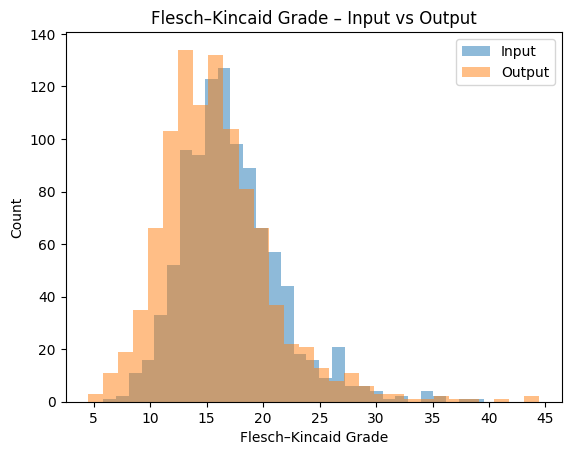

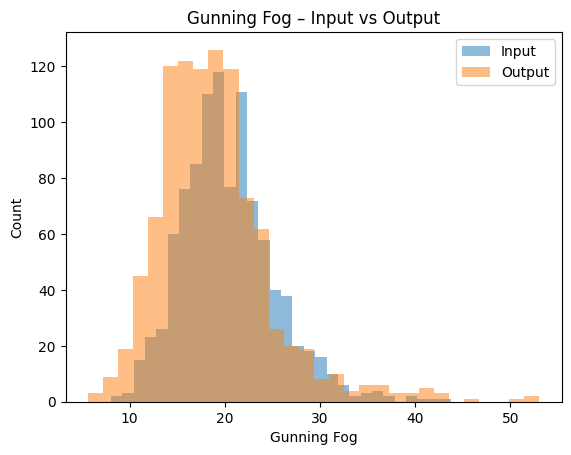

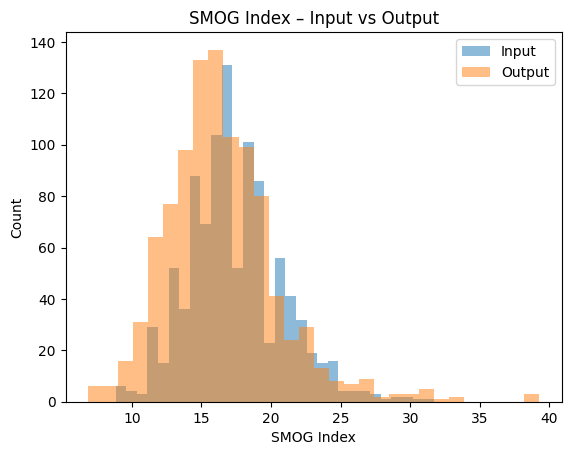

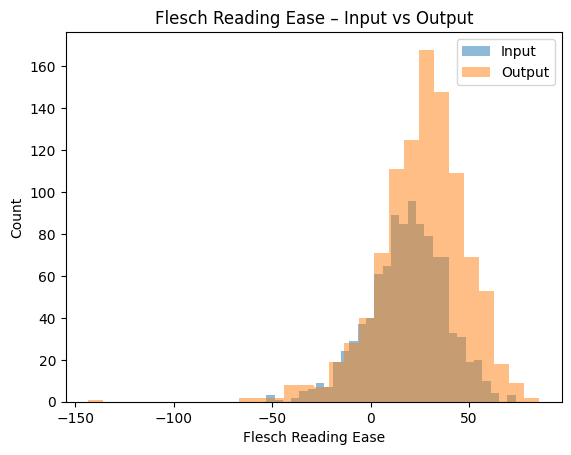

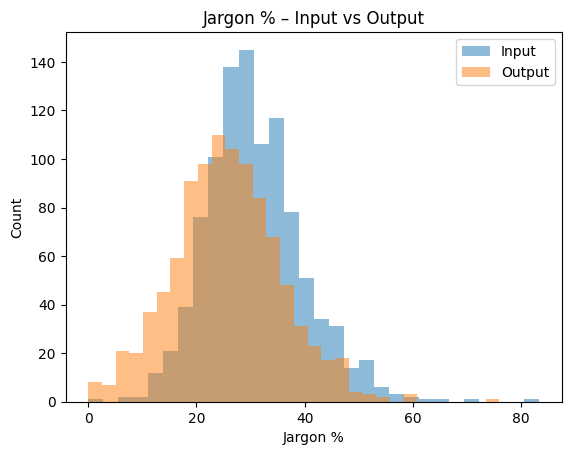

In [10]:
import matplotlib.pyplot as plt

df = clinical_with_pseudo.to_pandas()

metrics = [
    ("fk", "Flesch–Kincaid Grade"),
    ("gunning_fog", "Gunning Fog"),
    ("smog", "SMOG Index"),
    ("flesch_reading_ease", "Flesch Reading Ease"),
    ("jargon", "Jargon %"),
]

for key, title in metrics:
    in_col = f"{key}_in"
    out_col = f"{key}_out"

    plt.figure()
    plt.hist(df[in_col].dropna(), bins=30, alpha=0.5, label="Input")
    plt.hist(df[out_col].dropna(), bins=30, alpha=0.5, label="Output")
    plt.title(f"{title} – Input vs Output")
    plt.xlabel(title)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

One can see that the values are very similar between the input and the output, proving again that the model is not performing any kind of simplification.

### Part 5 - Glossary of medical terms and jargon - Milestone 3
The goal of this glossary is to automatically identify key medical terms appearing in trial descriptions and provide concise explanations that support user understanding. The glossary is designed as a complementary aid that helps users interpret clinical content without modifying the original text.

In earlier experiments, the glossary was built using a more limited biomedical NER model together with frequency-based heuristics. This approach worked reasonably well for identifying some diseases and chemical names, but it turned out to be too restrictive for clinical trial descriptions. Many important terms related to procedures, interventions, and outcomes were missed, and the frequency-based methods also introduced words that were not actually medical, which lowered the overall quality of the glossary.

To improve this, we switched to the scispaCy en_core_sci_lg model, which is better suited for scientific and biomedical text. Compared to the previous model, it captures a wider range of medical concepts that commonly appear in clinical trials. We also include abbreviation detection so that common medical acronyms and their full forms can be handled more reliably.


In [42]:
import time
import sqlite3
import requests
import spacy
import wikipediaapi

print("Loading scispaCy model...")
nlp = spacy.load("en_core_sci_lg")   # broader entity coverage than bc5cdr

try:
    from scispacy.abbreviation import AbbreviationDetector
    nlp.add_pipe("abbreviation_detector")
    HAS_ABBR = True
except Exception as e:
    print("AbbreviationDetector not available:", e)
    HAS_ABBR = False

wiki = wikipediaapi.Wikipedia(
    language="en",
    user_agent="MedicalGlossaryProject/1.0 (student_project)"
)

Loading scispaCy model...


C:\Users\Flaviu\miniconda3\envs\nlp\Lib\site-packages\spacy\language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


#### Definition Caching

To avoid repeatedly querying external resources for the same term definitions, a simple local caching mechanism is used. Definitions are stored in a lightweight SQLite database, where each term is saved together with its retrieved explanation. Before requesting a new definition, the cache is checked first, and if a definition already exists, it is reused.

This approach reduces unnecessary API calls, improves runtime efficiency, and ensures more consistent results when the same medical terms appear across multiple trial descriptions.

In [43]:
DB_PATH = "glossary_cache.sqlite"

def cache_init(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    cur.execute("""
        CREATE TABLE IF NOT EXISTS defs (
            key TEXT PRIMARY KEY,
            value TEXT
        )
    """)
    conn.commit()
    return conn

CONN = cache_init()

def cache_get(key, conn=CONN):
    cur = conn.cursor()
    cur.execute("SELECT value FROM defs WHERE key=?", (key,))
    row = cur.fetchone()
    return None if row is None else row[0]

def cache_set(key, value, conn=CONN):
    cur = conn.cursor()
    cur.execute("INSERT OR REPLACE INTO defs(key, value) VALUES (?, ?)", (key, value))
    conn.commit()

#### Medical Pattern Filtering
In addition to using a biomedical language model, we define a set of rule-based patterns to help distinguish medical terminology from general clinical or procedural language. These patterns include common medical suffixes, prefixes, and substrings that frequently appear in disease names, treatments, biological processes, and clinical outcomes.

To further reduce noise, we also maintain a small list of known non-medical words that often appear in trial descriptions but do not represent meaningful medical concepts. This combination of morphological patterns and explicit exclusions helps improve the precision of the glossary by filtering out common boilerplate terms while retaining medically relevant ones.

In [ ]:
MEDICAL_SUFFIXES = (
    "itis","emia","osis","opathy","oma","ectomy","otomy","algia","genic","lysis",
    "card","cardio","neuro","hepato","nephro","derm","pulmo","renal","onc",
    "immun","therap","toxic","metabol","gastro","osteo","myo","endo","hemo","hemat"
)

MEDICAL_PREFIXES = (
    "anti","hyper","hypo","brady","tachy","intra","inter","peri","post","pre",
    "sub","trans","micro","macro","poly","mono","neo","bio","cyto","histo",
    "neuro","cardio","hemo","hemat","derm","gastro","hepato","nephro","pulmo","osteo"
)

MEDICAL_SUBSTRINGS = (
    "chemo","radio","placebo","random","double-blind","biomarker","antibody",
    "infection","bacter","viral","fung","transfus","apheres","antibiot","antifung",
    "endpoint","efficacy","adverse","toxicity","mortality","morbidity"
)

KNOWN_NON_MEDICAL = {
    "daily","day","days","week","weeks","month","months","year","years",
    "patient","patients","study","trial","group","groups","arm","arms",
    "receive","receives","received","treatment","duration","oral","dose","doses",
    "changes",
}

#### Term Normalization and Medical Fallback Logic
Before extracting glossary entries, terms are first normalized to ensure consistent formatting and to remove unnecessary whitespace. A lightweight candidate filter is then applied to discard clearly invalid tokens, such as very short strings, numeric expressions, or measurement units, which are not meaningful as glossary entries.

For cases where relevant medical terms are not detected by the language model, a fallback heuristic is used at the single-word level. This heuristic combines word rarity with domain-specific signals, such as common medical prefixes, suffixes, substrings, and uppercase acronyms. At the same time, a blacklist of known non-medical terms is applied to prevent common trial-related words from being incorrectly classified as medical terminology. Together, these steps help increase coverage while keeping the glossary focused on genuinely medical concepts.


In [45]:
def normalize_term(t: str) -> str:
    t = t.strip()
    t = re.sub(r"\s+", " ", t)
    return t

def is_candidate_term(term: str) -> bool:
    if not term:
        return False
    if len(term) < 3:
        return False
    # reject mostly numeric
    if re.fullmatch(r"[\d\W_]+", term):
        return False
    # reject pure units / trivial tokens
    if term.lower() in {"mg", "ml", "cm", "mm", "kg", "bid", "tid", "qid", "prn"}:
        return False
    return True

def is_probably_medical_word(word: str, zipf_thresh=4.5) -> bool:
    """
    Fallback heuristic for SINGLE TOKENS not found by NER:
    - must be rare-ish (Zipf below threshold) OR be an uppercase acronym
    - must pass blacklist
    - must have medical-looking morphology (prefix/suffix/substring)
    """
    if not word:
        return False

    w = word.strip()
    wl = w.lower()

    # Skip boilerplate / obvious non-medical
    if wl in KNOWN_NON_MEDICAL:
        return False

    # Allow acronyms (COPD, CNS, MI)
    if w.isupper() and w.isalpha() and 2 <= len(w) <= 8:
        return True

    # Must be a simple word token (letters or hyphen)
    if not re.fullmatch(r"[a-z][a-z\-]+", wl):
        return False

    # Rarity filter: if it's common English, don't treat it as medical fallback
    if zipf_frequency(wl, "en") >= zipf_thresh:
        return False

    if any(wl.endswith(s) for s in MEDICAL_SUFFIXES):
        return True
    if any(wl.startswith(p) for p in MEDICAL_PREFIXES):
        return True
    if any(s in wl for s in MEDICAL_SUBSTRINGS):
        return True

    return False



#### Definition Retrieval from External Sources

To provide explanations for the extracted medical terms, definitions are retrieved from external knowledge bases. The primary source used is BioPortal, accessed through its public API, with the MeSH ontology selected due to its broad coverage and standard use in biomedical contexts. BioPortal allows access to structured medical definitions that are well suited for clinical terminology.

When no suitable definition is found in BioPortal, Wikipedia is used as a fallback source. Wikipedia summaries are generally more accessible and easier to understand for non-expert users, making them appropriate for patient-facing explanations. All retrieved definitions are cached locally to reduce repeated requests and improve overall efficiency.


In [46]:
BIOPORTAL_KEY = "8bac14aa-d666-4338-b2aa-5fd0ac6e2dcb" #created an account to get this
BIOPORTAL_BASE = "https://data.bioontology.org"
BIOPORTAL_ONTOLOGIES = ["MESH"]

def bioportal_definition(term: str) -> str | None:
    if not BIOPORTAL_KEY:
        return None

    cache_key = f"bioportal::{term.lower()}"
    cached = cache_get(cache_key)
    if cached is not None:
        return cached if cached != "" else None

    headers = {"Authorization": f"apikey token={BIOPORTAL_KEY}"}
    params = {
        "q": term,
        "ontologies": ",".join(BIOPORTAL_ONTOLOGIES),
        "require_exact_match": "false",
        "require_definitions": "true",
        "pagesize": 5
    }

    try:
        r = requests.get(f"{BIOPORTAL_BASE}/search", headers=headers, params=params, timeout=20)
        if r.status_code != 200:
            cache_set(cache_key, "")
            return None

        data = r.json()
        # Look for the first hit that has a definition
        for hit in data.get("collection", []):
            defs = hit.get("definition") or []
            if defs:
                # defs can be list of strings
                definition = defs[0].strip()
                if definition:
                    cache_set(cache_key, definition)
                    return definition

        cache_set(cache_key, "")
        return None

    except Exception:
        cache_set(cache_key, "")
        return None

#wikipedia only used as fallback
def wikipedia_definition(term: str, max_sentences=2) -> str | None:
    cache_key = f"wiki::{term.lower()}"
    cached = cache_get(cache_key)
    if cached is not None:
        return cached if cached != "" else None

    try:
        page = wiki.page(term)
        if not page.exists():
            cache_set(cache_key, "")
            return None
        summary = page.summary.strip()
        if not summary:
            cache_set(cache_key, "")
            return None
        sents = summary.split(". ")
        short = ". ".join(sents[:max_sentences]).strip()
        if not short.endswith("."):
            short += "."
        cache_set(cache_key, short)
        return short
    except Exception:
        cache_set(cache_key, "")
        return None

def get_definition(term: str) -> str:
    # 1) BioPortal (MeSH) if key is available
    d = bioportal_definition(term)
    if d:
        return d

    # 2) Wikipedia fallback
    d = wikipedia_definition(term)
    if d:
        return d

    return "Definition not found."


#### Medical Term Extraction

Medical terms are extracted from the trial description using a multi-step approach. First, named entities identified by the scispaCy model are collected, as these provide the most reliable signal for medically relevant concepts. Detected terms are normalized and deduplicated to ensure consistent glossary entries.

Next, abbreviation detection is applied to capture both short forms and their corresponding expanded terms, which are common in clinical trial text. Finally, a fallback step is used to identify additional single-word medical terms that may not have been recognized as entities. This fallback relies on domain-specific heuristics to avoid introducing non-medical vocabulary while improving coverage.


In [51]:
def extract_terms(text: str, max_terms=70) -> list[str]:
    doc = nlp(text)

    terms = []
    seen = set()

    # A) Entities from scispaCy
    for ent in doc.ents:
        t = normalize_term(ent.text)
        if is_candidate_term(t) and t.lower() not in seen:
            seen.add(t.lower())
            terms.append(t)

    # B) Abbreviations: map "MI" -> "myocardial infarction" when detectable
    if HAS_ABBR and hasattr(doc._, "abbreviations"):
        for abbr in doc._.abbreviations:
            short = normalize_term(str(abbr))
            longf = normalize_term(str(abbr._.long_form))
            # store the short form but define by long form later
            if is_candidate_term(short) and short.lower() not in seen:
                seen.add(short.lower())
                terms.append(short)
            if is_candidate_term(longf) and longf.lower() not in seen:
                seen.add(longf.lower())
                terms.append(longf)

    # C) Optional fallback: add rare single-word jargon not already captured
    for tok in doc:
        if tok.is_stop or tok.is_punct:
            continue
        w = tok.text.strip()
        if w.lower() in seen:
            continue
        if is_probably_medical_word(w):
            seen.add(w.lower())
            terms.append(w)

    return terms[:max_terms]


#### Glossary Construction

The final glossary is created by combining the extracted medical terms with their corresponding definitions. For each term identified in the text, a definition is retrieved using the previously described lookup strategy. When BioPortal is used, a short delay is introduced between requests to avoid overloading the external API.

The resulting glossary is returned as a dictionary that maps each medical term to its explanation, allowing it to be easily integrated into later analysis or user-facing components.


In [48]:
def generate_glossary(text: str, sleep_s=0.2) -> dict[str, str]:
    glossary = {}
    terms = extract_terms(text)

    for term in terms:
        # polite rate limiting if using BioPortal
        if BIOPORTAL_KEY:
            time.sleep(sleep_s)

        definition = get_definition(term)
        glossary[term] = definition

    return glossary


#### Example Usage
To demonstrate the glossary generation process, we apply the pipeline to a sample clinical trial description. The text includes typical trial sections such as objectives, interventions, and outcomes, and contains a range of medical terminology commonly found in real-world clinical trial data.

The generated glossary lists the extracted medical terms together with their corresponding definitions, illustrating how the approach can be used to support understanding of clinical trial descriptions in practice.


In [22]:
text_data = """
PRIMARY OBJECTIVES: I. To determine the effects of the iron-chelating agent deferasirox on changes in: neutrophil function; macrophage function; lymphocyte function.

SECONDARY OBJECTIVES: I. To determine the effect of chelation on the incidence of bacterial, viral and fungal infections documented by clinical, microbiologically-proven versus radiologically-proven criteria. II. To determine the effect of iron chelation on mortality and morbidity with incidence of the following parameters: Need for hospitalization; Duration of hospitalization; Need for ventilatory support; Need for exchange transfusion/apheresis; Need for treatment with antifungals or antibiotics for documented infections.

OUTLINE: Patients receive oral deferasirox once daily for up to 6 months or until blood counts recover in the absence of disease progression or unacceptable toxicity.
"""

gloss = generate_glossary(text_data)

for k, v in gloss.items():
    print(f"\n - {k}\n   {v}")



 - PRIMARY OBJECTIVES
   The purposes, missions, and goals of an individual organization or its units, established through administrative processes. It includes an organization's long-range plans and administrative philosophy.

 - effects of
   Activities which affect organs and systemic functions without regard to a particular disease.

 - iron-chelating agent
   Organic chemicals that form two or more coordination links with an iron ion. Once coordination has occurred, the complex formed is called a chelate. The iron-binding porphyrin group of hemoglobin is an example of a metal chelate found in biological systems.

 - deferasirox
   A triazole and benzoate derivative that acts as a selective iron chelator. It is used in the management of chronic IRON OVERLOAD due to blood transfusion or non-transfusion dependent THALASSEMIA.

 - changes
   Physiological changes that occur in bodies after death.

 - neutrophil function
   The diffusion or accumulation of neutrophils in tissues or ce

### Part 6 - Groq and LLAMA 3.3 - Milestone 3
Our solution to the failed experiments of training our own models for summarization and simplification was to use an existing LLM with an API and ask him to perform the summarization and simplification into one single step, by asking for a patient-readable summary.

Load Groq Client

In [1]:
import os
os.environ["GROQ_API_KEY"] = "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"

from groq import Groq

client = Groq(api_key=os.environ["GROQ_API_KEY"])

Load Filtered Dataset

In [30]:
ds = load_from_disk("data/filtered_ds")
subset_size = 10
ds = ds.shuffle(seed=42).select(range(subset_size))
print("Rows loaded:", len(ds))

Rows loaded: 10


Function combining the fields for Summarization

In [2]:
def build_input(example):
    desc = example.get("detailed_description") or ""
    brief = example.get("brief_summary") or ""
    elig = example.get("eligibility_criteria") or ""
    brief_title = example.get("brief_title") or ""
    off_title = example.get("official_title") or ""
    study_type = example.get("study_type") or ""
    study_pop = example.get("study_population") or ""
    min_age = example.get("minimum_age") or ""
    max_age = example.get("maximum_age") or ""
    sex = example.get("sex") or ""
    healthy_vol = example.get("healthy_volunteers") or ""

    return (
        "Detailed Description:\n" + desc.strip() + "\n\n" +
        "Brief Summary:\n" + brief.strip() + "\n\n" +
        "Eligibility Criteria:\n" + elig.strip() + "\n\n" +
        "Brief Title:\n" + brief_title.strip() + "\n\n" +
        "Official Title:\n" + off_title.strip() + "\n\n" +
        "Study Type:\n" + study_type.strip() + "\n\n" +
        "Study Population:\n" + study_pop.strip() + "\n\n" +
        "Minimum Age:\n" + str(min_age) + "\n\n" +
        "Maximum Age:\n" + str(max_age) + "\n\n" +
        "Sex:\n" + sex.strip() + "\n\n" +
        "Healthy Volunteers:\n" + str(healthy_vol)
    )

Choose the model

In [1]:
from groq import Groq
import os

client = Groq(api_key=os.environ["GROQ_API_KEY"])

models = client.models.list()

for m in models.data:
    print(m.id)


KeyboardInterrupt



In [39]:
def summarize_clinical(text):
    prompt = f"""
    Summarize the following clinical trial information into a,
    medically accurate, patient-friendly paragraph. Avoid unnecessary jargon.

    {text}
    """

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=200,
    )

    return response.choices[0].message.content


Groq Summarization Function which produces a paragraph

In [42]:
from tqdm import tqdm

summaries = []

print("Generating summaries with Llama-3-70B on Groq...")

for row in tqdm(ds, total=len(ds)):
    combined_text = build_input(row)
    summary = summarize_clinical(combined_text)
    summaries.append(summary)

Generating summaries with Llama-3-70B on Groq...


100%|██████████| 10/10 [00:28<00:00,  2.84s/it]


In [44]:
for s in summaries:
    print(f"--- Summary  ---")
    print(s)
    print()

--- Summary  ---
If you have locally advanced breast cancer, you may be interested in a research study that combines chemotherapy and a medication called bevacizumab to help shrink your tumor before surgery. Bevacizumab works by stopping the growth of new blood vessels that feed the tumor, which can help slow down the tumor's growth. The chemotherapy medications used in this study are designed to kill cancer cells directly. The goal of this study is to see how well this combination of treatments works to shrink tumors and make them easier to remove surgically. You will receive the chemotherapy and bevacizumab before surgery, and then bevacizumab alone after surgery. The study will also look at any side effects you may experience and how the treatment affects your heart and overall recovery from surgery. To be eligible for this study, you must be at least 18 years old, have a certain type of breast cancer, and meet other specific criteria. Your doctor can help you determine if this stud

The above code takes so much time to run. So we are implementing batch processing below to make it robust and fast.
It implements a scalable, fault-tolerant batch summarization pipeline designed for large-scale clinical text processing. Given the size of the dataset (~344,000 records), issuing individual API requests for each entry was computationally prohibitive and susceptible to rate limitations, network faults, and system interruptions.

To address these challenges, this implementation employs a batch-oriented approach, grouping multiple clinical trial records into a single request to the Groq Llama-3.3-70B-versatile model. The pipeline incorporates several robustness features commonly used in large-scale NLP workflows:
    • Batch processing to reduce the number of API calls and improve throughput
    • Exponential backoff and retry logic to manage transient API or network failures
    • Persistent checkpointing of progress, enabling seamless resumption after interruptions without recomputation
    • Periodic intermediate dataset serialization to safeguard against data loss
    • Structured JSON-based responses to ensure deterministic parsing and mapping between input trials and generated summaries

This design supports high-volume text summarization with strong guarantees of reliability and reproducibility. The final output augments the dataset with a "combined_summary" field containing concise, patient-readable (2–3 sentence) abstractive summaries synthesized from the detailed description, brief summary, and eligibility criteria of each clini

Now we have run the code with subset because of the rate limit constraint of groq.cal trial.
f each clinical trial.


In [3]:
from datasets import load_from_disk

# Loading full dataset & create subset
full_ds = load_from_disk("data/filtered_ds")

subset_size = 100
ds = full_ds.select(range(subset_size))

print("Using subset of size:", len(ds))

# 2. BEGIN BATCH PIPELINE
import os
import json
import time
import re
from groq import Groq
from tqdm import tqdm

# Configuration
MODEL_ID = "llama-3.3-70b-versatile"
BATCH_SIZE = 1
MAX_TOKENS = 300
TEMPERATURE = 0.2
SAVE_EVERY_N_BATCHES = 100
CHECKPOINT_PATH = "groq_progress_subset.json"
OUTPUT_DS_PATH = "clinical_trial_summaries_subset"
N = len(ds)

# Safety: load API key from env
if "GROQ_API_KEY" not in os.environ:
    raise RuntimeError("Set your Groq API key in the environment variable GROQ_API_KEY before running this cell.")
client = Groq(api_key=os.environ["GROQ_API_KEY"])

print(f"Loaded subset with {N} rows")


# -----------------------------
# Load / Save checkpoint
# -----------------------------
def load_checkpoint(path):
    if os.path.exists(path):
        print("Loading checkpoint:", path)
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return data.get("next_index", 0), data.get("summaries", [])
    return 0, []

def save_checkpoint(path, next_index, summaries):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump({"next_index": next_index, "summaries": summaries}, f)
    os.replace(tmp, path)
    print(f"Checkpoint saved. next_index={next_index}, summaries={len(summaries)}")

# -----------------------------
# Prompt builder for JSON output
# -----------------------------
def make_batch_prompt(batch_items):
    parts = []
    parts.append("Summarize the following clinical trial information into a, medically accurate, patient-friendly paragraph. Avoid unnecessary jargon.")
    parts.append("Return the summaries as a STRICT JSON array of objects, each containing:")
    parts.append("  - \"index\": the input index")
    parts.append("  - \"summary\": the generated summary\n")
    parts.append('Example: [{"index": 0, "summary": "This trial evaluates ..."}]\n')
    parts.append("Now summarize the following trials:\n")

    for idx, text in batch_items:
        parts.append(f"TRIAL_INDEX: {idx}\n{text}\n")
    return "\n".join(parts)

# -----------------------------
# JSON extraction helper
# -----------------------------
def extract_json_array_from_text(text):
    text = text.strip()
    try:
        return json.loads(text)
    except:
        pass

    m = re.search(r"\[.*\]", text, flags=re.DOTALL)
    if m:
        candidate = m.group(0)
        try:
            return json.loads(candidate)
        except:
            pass
    return None

# -----------------------------
# Batch summarization with retries
# -----------------------------
def summarize_batch(batch_items, max_retries=5, initial_backoff=1.0):
    prompt = make_batch_prompt(batch_items)
    attempt = 0

    while attempt < max_retries:
        attempt += 1
        try:
            response = client.chat.completions.create(
                model=MODEL_ID,
                messages=[{"role": "user", "content": prompt}],
                temperature=TEMPERATURE,
                max_tokens=MAX_TOKENS,
            )
            raw = response.choices[0].message.content
            parsed = extract_json_array_from_text(raw)

            if parsed is None:
                raise ValueError("Could not parse JSON array.")

            for obj in parsed:
                if "index" not in obj or "summary" not in obj:
                    raise ValueError("JSON missing required keys.")

            return parsed

        except Exception as e:
            print(f"[Warning] Batch attempt {attempt}/{max_retries} failed: {e}")
            if attempt >= max_retries:
                raise
            sleep_time = initial_backoff * (2 ** (attempt - 1))
            print(f"Sleeping {sleep_time:.1f} seconds...")
            time.sleep(sleep_time)

# -----------------------------
# Main summarization loop
# -----------------------------
start_index, completed_summaries = load_checkpoint(CHECKPOINT_PATH)
summary_map = {item["index"]: item["summary"] for item in completed_summaries}

print("Resuming from index:", start_index)

batch_count = 0
i = start_index
pbar = tqdm(total=N, initial=start_index)
already_saved = False
try:
    while i < N:
        batch_items = []
        for j in range(i, min(i + BATCH_SIZE, N)):
            if j not in summary_map:
                batch_items.append((j, build_input(ds[j])))

        if not batch_items:
            i += BATCH_SIZE
            pbar.update(BATCH_SIZE)
            continue

        parsed = summarize_batch(batch_items)
        for obj in parsed:
            summary_map[obj["index"]] = obj["summary"].strip()

        i_next = min(i + BATCH_SIZE, N)
        batch_count += 1

        save_checkpoint(CHECKPOINT_PATH, i_next, [{"index": k, "summary": v} for k, v in summary_map.items()])

        pbar.update(len(batch_items))
        i = i_next
except:
    final_summaries = [summary_map.get(idx, "") for idx in range(i)]
    ds = ds.select(range(i)).add_column("combined_summary", final_summaries)
    import shutil
    from pathlib import Path
    if Path(OUTPUT_DS_PATH).exists():
        shutil.rmtree(OUTPUT_DS_PATH)
    ds.save_to_disk(OUTPUT_DS_PATH)
    print("Subset summarization complete!")
    print("Saved to:", OUTPUT_DS_PATH)
    print(len(ds))
    already_saved = True
finally:
    pbar.close()

# -----------------------------
# Save final subset output
# -----------------------------
if not already_saved:
    final_summaries = [summary_map.get(idx, "") for idx in range(N)]
    ds = ds.add_column("combined_summary", final_summaries)
    import shutil
    from pathlib import Path
    if Path(OUTPUT_DS_PATH).exists():
        shutil.rmtree(OUTPUT_DS_PATH)
    ds.save_to_disk(OUTPUT_DS_PATH)

    print("Subset summarization complete!")
    print("Saved to:", OUTPUT_DS_PATH)

C:\Users\Flaviu\miniconda3\envs\nlp\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Using subset of size: 100
Loaded subset with 100 rows
Loading checkpoint: groq_progress_subset.json
Resuming from index: 57


 58%|█████▊    | 58/100 [00:00<00:31,  1.34it/s]

Checkpoint saved. next_index=58, summaries=58


 59%|█████▉    | 59/100 [00:01<00:25,  1.62it/s]

...

Checkpoint saved. next_index=99, summaries=99


100%|██████████| 100/100 [03:18<00:00,  4.61s/it]

Checkpoint saved. next_index=100, summaries=100


Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Subset summarization complete!
Saved to: clinical_trial_summaries_subset


While looking at some sample results, one can see that the simplified summaries are much better than those resulted in the initial trials. The model knows how to pick information from all the trial features and overall the look easily understandable.

In [33]:
#see the results
from datasets import load_from_disk

ds_out = load_from_disk("clinical_trial_summaries_subset")

for i in range(5):
    print(f"--- Summary {i} ---")
    print(ds_out[i]["combined_summary"])
    print()

--- Summary 0 ---
This clinical trial is studying a medication called deferasirox to see if it can help remove excess iron from the body in patients with certain blood disorders, such as leukemia or lymphoma, who have received multiple blood transfusions. The trial aims to determine if deferasirox can improve the body's immune function, reduce the risk of infections, and decrease the need for hospitalization or other medical interventions. Patients will take deferasirox orally once a day for up to 6 months to see if it can help reduce iron overload and improve their overall health.

--- Summary 1 ---
This study is looking at how well two different hip replacement stems work. Fifty patients with degenerative joint disease, such as osteoarthritis, will be randomly assigned to receive one of the two stems. The study will track how the new hip moves over two years. To be in the study, patients must be between 18 and 70 years old, able to understand Dutch, and willing to come back for follo

The same thing can be observed while looking at a summary in contrast with the initial features of the trial

In [4]:
from datasets import load_from_disk

ds_out = load_from_disk("clinical_trial_summaries_subset")

def show_example(index):
    print("======================================")
    print(f"Example {index}")
    print("======================================\n")

    print("Detailed Description:\n")
    print(ds_out[index]["detailed_description"][:600], "\n")

    print("Brief Summary:\n")
    print(ds_out[index]["brief_summary"][:400], "\n")

    print("Eligibility Criteria:\n")
    print(ds_out[index]["eligibility_criteria"][:400], "\n")

    print("Generated Summary:\n")
    print(ds_out[index]["combined_summary"])
    print("\n--------------------------------------\n")

# Show example 0
show_example(0)


Example 0

Detailed Description:

PRIMARY OBJECTIVES: I. To determine the effects of the iron-chelating agent deferasirox on changes in: neutrophil function; macrophage function; lymphocyte function.

SECONDARY OBJECTIVES: I. To determine the effect of chelation on the incidence of bacterial, viral and fungal infections documented by clinical, microbiologically-proven versus radiologically-proven criteria. II. To determine the effect of iron chelation on mortality and morbidity with incidence of the following parameters: Need for hospitalization; Duration of hospitalization; Need for ventilatory support; Need for exchange tran 

Brief Summary:

RATIONALE: Deferasirox may remove excess iron from the body caused by blood transfusions.

PURPOSE: This clinical trial studies deferasirox in treating iron overload caused by blood transfusions in patients with hematologic malignancies. 

Eligibility Criteria:

Inclusion Criteria:

* Patients must have a pathology confirmed diagnosis of one of 

Now let's look again at how are these simplified summaries performing in terms of readability compared to the initial brief_summary

In [5]:
import textstat
from typing import Dict, List
from wordfreq import zipf_frequency


def readability_metrics(text: str) -> Dict[str, float]:
    """Compute basic readability metrics for a text."""
    return {
        "fk_grade": textstat.flesch_kincaid_grade(text),
        "gunning_fog": textstat.gunning_fog(text),
        "smog_index": textstat.smog_index(text),
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
    }

def tokenize_words(text: str) -> List[str]:
    return re.findall(r"\b[a-zA-Z][a-zA-Z\-]+\b", text.lower())


def is_common_word(word: str, threshold: float = 4.5) -> bool:
    """
    Uses Zipf frequency (0–7, higher = more common).
    ~4–5: common everyday English; <4: rare/technical.
    """
    return zipf_frequency(word, "en") >= threshold

def jargon_ratio(text: str, threshold: float = 4.5, min_len: int = 4) -> float:
    """
    Approximate jargon density using wordfreq.
    Returns % of tokens considered jargon.
    """
    words = tokenize_words(text)
    if not words:
        return 0.0
    jargon_words = [
        w for w in words
        if len(w) >= min_len and not is_common_word(w, threshold)
    ]
    return 100.0 * len(jargon_words) / len(words)

In [6]:
IN_COL = "brief_summary"
OUT_COL = "combined_summary"

def add_metrics(example):
    in_text = example.get(IN_COL, "") or ""
    out_text = example.get(OUT_COL, "") or ""

    in_r = readability_metrics(in_text)
    out_r = readability_metrics(out_text)

    return {
        "fk_in": in_r["fk_grade"],
        "gunning_fog_in": in_r["gunning_fog"],
        "smog_in": in_r["smog_index"],
        "flesch_reading_ease_in": in_r["flesch_reading_ease"],
        "jargon_in": jargon_ratio(in_text),

        "fk_out": out_r["fk_grade"],
        "gunning_fog_out": out_r["gunning_fog"],
        "smog_out": out_r["smog_index"],
        "flesch_reading_ease_out": out_r["flesch_reading_ease"],
        "jargon_out": jargon_ratio(out_text),
    }

ds_with_metrics = ds_out.map(add_metrics, desc="Computing readability + jargon")

Computing readability + jargon:   0%|          | 0/100 [00:00<?, ? examples/s]

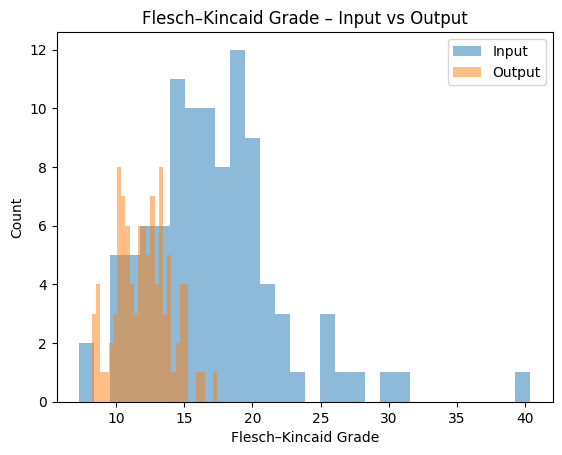

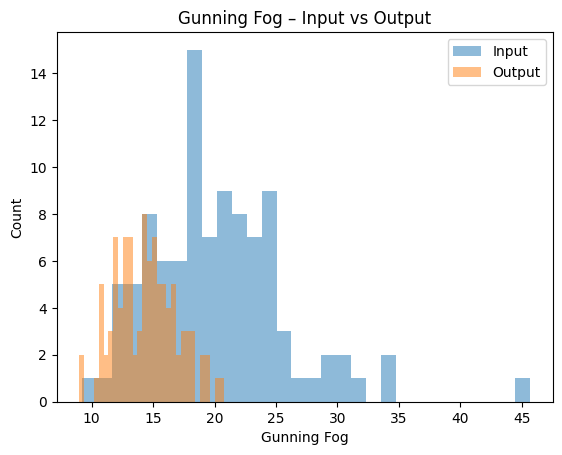

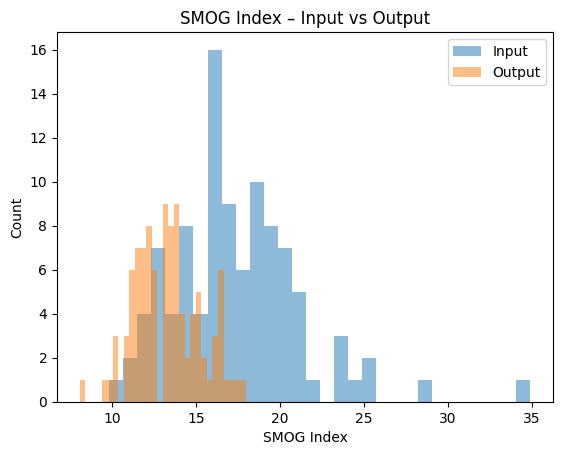

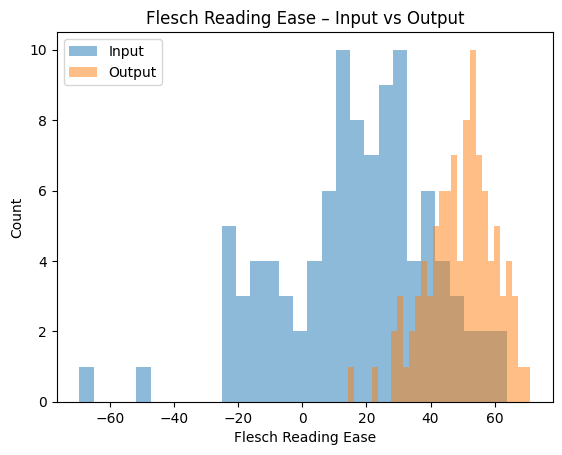

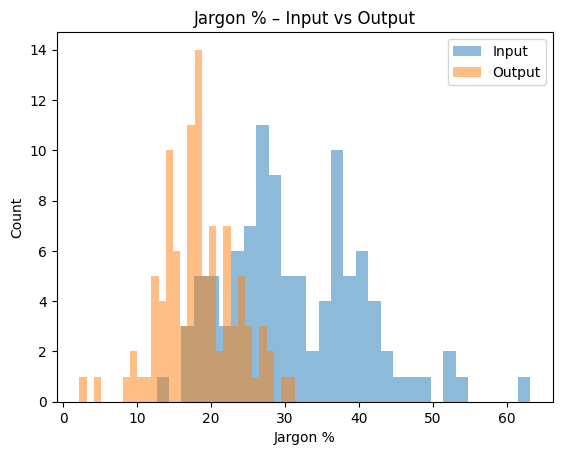

In [7]:
import matplotlib.pyplot as plt

df = ds_with_metrics.to_pandas()

metrics = [
    ("fk", "Flesch–Kincaid Grade"),
    ("gunning_fog", "Gunning Fog"),
    ("smog", "SMOG Index"),
    ("flesch_reading_ease", "Flesch Reading Ease"),
    ("jargon", "Jargon %"),
]

for key, title in metrics:
    in_col = f"{key}_in"
    out_col = f"{key}_out"

    plt.figure()
    plt.hist(df[in_col].dropna(), bins=30, alpha=0.5, label="Input")
    plt.hist(df[out_col].dropna(), bins=30, alpha=0.5, label="Output")
    plt.title(f"{title} – Input vs Output")
    plt.xlabel(title)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

One can see an amazing performance improvement, across all the metrics, from the Flesch–Kincaid Grade to the jargon percentage, meaining that our goal was achieved: to generate better understandable summary for a trial so that the patient can easily figure out what the trail is about and if he/she can participate in it and to create a glossary of jaron and medical terms for non-specialized or non-english native patients to navigate and understand.

### Use case of how a patient would interact with our system
With the right amount of computational power, one could generate the simplified summaries and associated metrics for the entire dataset and could therefore enhance the usability of it by expanding it with these simplified summaries.

In [53]:
dataset_final = load_from_disk("clinical_trial_summaries_subset")
dataset_final = dataset_final.map(add_metrics, desc="Computing readability + jargon")

# Patient selects a desired trial
i = 5

# Patient sees the current description and summary and does not understand much
print("\n --- Description --- \n")
print(dataset_final[i]["detailed_description"])
print("\n --- Summary --- \n")
print(dataset_final[i]["brief_summary"])

# Patient wants a simplified summary for his understanding
print("\n --- Simplified summary --- \n")
print(dataset_final[i]["combined_summary"])

# Patient understands better the trial, which can also be seen in the metrics for readability and understanding:
metrics = [
    ("fk", "Flesch–Kincaid Grade"),
    ("gunning_fog", "Gunning Fog"),
    ("smog", "SMOG Index"),
    ("flesch_reading_ease", "Flesch Reading Ease"),
    ("jargon", "Jargon %"),
]

for key, title in metrics:
    in_col = f"{key}_in"
    out_col = f"{key}_out"
    print("\n --- Metric: " + title + " ---\n")
    print("Brief summary: ", dataset_final[i][in_col])
    print("Simplified summary: ", dataset_final[i][out_col])

# Patient wants a glossary for all the medical terms, so he can understand them better:
text_data = dataset_final[i]["brief_summary"] + dataset_final[i]["combined_summary"] + dataset_final[i]["detailed_description"]
gloss = generate_glossary(text_data)

print("\n -- Glossary of jargons and medical terms --- \n")
for k, v in gloss.items():
    print(f"\n - {k}\n   {v}")


 --- Description --- 

Study procedure includes: 1. Eligibility assessment according to inclusion and exclusion criteria. 2. Administration of questionnaires and scales for the characterization of cognitive and psychological features related with BMD/DMD and OI : Wechsler Intelligence Scale for Children 4th Edition (WISC-IV), Raven's Progressive Matrices; NEPSY-II; The Child Behavior Checklist (CBCL); PedsQL; Toronto Alexithymia Scale (TAS-20); Emotion Regulation Questionnaire (ERQ); Emotion Regulation Questionnaire for Children and Adolescents (ERQ-CA); Multidimensional Assessment of Interoceptive Awareness (MAIA); Body Shape Questionnaire (BSQ-14); and the Autism Spectrum Quotient (AQ, adult or child version) 3. Administration of experimental tasks. The Comfort-Distance Task (CDT) to measure the interpersonal comfort distance, the task will be implemented in immersive virtual reality by means of head-mounted displays (OCULUS ©2024 Meta). Interoceptive accuracy will be measured throu